# Lab08：從偵測到根因，一步一個試驗

## 這一節怎麼走

前面五節每一節教一類方法。這一節不介紹新方法，它示範一件事：拿到資料之後，**怎麼決定下一步要試
什麼**。

規則只有一條，從頭到尾不變。

> 每一步跑一個試驗，量一個數字，讀出這個數字暴露的缺陷，缺陷指定下一步。

每一步都會出現三樣東西：一次執行、一個量到的值、一句「所以下一步要試什麼」。試到後來會遇到兩種
結局，一種是缺陷修好了，另一種是量到的進步已經小於雜訊。第二種比第一種重要，因為它是停手的訊號，
而多數人不知道什麼時候該停。

## 四個部分，重量不一樣

**目標是偵測。** 第 1 到第 9 步。這部分會比想像中早結束，因為它比想像中簡單。

**基礎是進階異常指標。** 第 10 到第 18 步。偵測停手之後才看得出來，這些指標真正的價值不在偵測，
在它們餵給根因分析的東西。

**承重的是根因分析。** 第 19 到第 33 步，全課最長的一段。偵測告訴你有事，根因才告訴你要做什麼。

**最後交給 LLM 解讀。** 第 34 到第 37 步。你會親手把 prompt 貼進聊天視窗，把回覆貼回來，讓
notebook 執行模型要求的工具，再把結果貼回去。這是 agentic pipeline 真正的樣子，只是傳話的人是你。

## 程式在哪裡

**每一個做出判斷的函式都定義在這份 notebook 裡**，就在第一次用到它的那一格，可以直接讀、直接改。
`lib/` 只放三種東西：讀檔、畫圖、記錄進度。改動 `lib/` 不會改變任何一個結論，改動 notebook 裡的
函式會。

## 你要做的事

每一步都有一格程式可以改。標了 **`你的選擇`** 的那幾格是刻意留給你的：改一個數字，重跑一次，看
成績單怎麼動。**先照原樣跑完一遍，再回頭改。** 第一遍看的是路，第二遍才是自己走。

## 你需要準備的

一個可以開的 LLM 聊天視窗，任何一個都行。前 33 步不需要它。

全部跑完大約一分鐘。讀完並且動手改過，大約兩小時。

In [1]:
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.covariance import LedoitWolf, MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# lib/ 只有三種東西：讀檔、畫圖、記錄進度。沒有任何一個統計決定藏在裡面。
from lib.lib import set_figure_style, C, PORT_C, heatmap, anomaly_windows
from lib.loader import load_telemetry, load_catalog, load_calendar
from lib.ladder import Ladder, show_prompt

set_figure_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

SEED = 0
CADENCE_S = 300.0
MAD_TO_SIGMA = 1.4826
BUDGET = 0.5                      # false onsets per port per day, the number Lab04 used

ladder = Ladder()                 # 每一步的結果記在這裡，最後一步把整條路畫出來


def wrong_way(label, run):
    # 故意走錯的那一條路。錯誤有兩種，這個函式把兩種都攤開來給你看。
    # 會爆的那種其實比較好，因為它會自己說話。安靜給出一個看起來合理的錯答案，才是危險的那種。
    print(f"=== 錯誤示範：{label} ===")
    try:
        outcome = run()
    except Exception as exc:
        print(f"  大聲失敗 {type(exc).__name__}: {exc}")
        print("  這一種還算好運，程式自己停下來了。")
        return None
    print(f"  沒有報錯，結果是：{outcome}")
    print("  沒有報錯不代表算對了。這一種要靠你自己看出來。")
    return outcome

telemetry = load_telemetry()
catalog = load_catalog()
calendar = load_calendar()
print(f"{len(telemetry):,} rows, {telemetry['port_id'].nunique()} ports, "
      f"{telemetry['timestamp'].min()} -> {telemetry['timestamp'].max()}")
display(catalog)

43,200 rows, 5 ports, 2026-02-01 00:00:00 -> 2026-03-02 23:55:00


,event_id,event_type,port_id,start_time,periods_5min,description,end_time
0,A,business_traffic_growth,port-id7430,2026-02-04 09:00:00,24,正常業務流量增加,2026-02-04 10:55:00
1,B,small_packet_scan,port-id7428,2026-02-06 13:10:00,10,大量小封包 / 掃描,2026-02-06 13:55:00
2,C,large_file_backup,port-id7431,2026-02-08 01:00:00,36,大檔案傳輸 / 備份,2026-02-08 03:55:00
3,D,queue_congestion,port-id7427,2026-02-11 15:20:00,14,頻寬壅塞 / Queue 滿,2026-02-11 16:25:00
4,E,link_quality_issue,port-id7429,2026-02-14 10:35:00,8,線路品質問題,2026-02-14 11:10:00
5,F,load_sensitive_link_issue,port-id7427,2026-02-17 16:00:00,18,高負載下線路不穩,2026-02-17 17:25:00
6,G,broadcast_storm,MULTI,2026-02-19 11:30:00,12,Broadcast Storm / L2 Loop,2026-02-19 12:25:00
7,H,multicast_flooding,MULTI,2026-02-22 20:05:00,18,Multicast Flooding,2026-02-22 21:30:00
8,I,abnormal_device_sender,port-id7430,2026-02-25 09:45:00,16,異常設備大量發送,2026-02-25 11:00:00
9,J,unknown_protocol_scan,port-id7428,2026-02-27 14:15:00,10,Unknown Protocol,2026-02-27 15:00:00


---
# 第一部　目標：偵測

## 第 1 步　試驗：這些欄位可以當累計值讀嗎

SNMP 的 octet counter 只會往上加，要算速率必須先做差分。差分之前得先確認它真的是 counter，方法是
量相鄰兩筆的差有多少是非負的。真的 counter 會是九成九以上。

In [2]:
RAW_COLUMNS = ["INOCTETS", "OUTOCTETS", "INERRORS", "OUTERRORS",
               "INUCASTPKTS", "OUTUCASTPKTS", "INNUCASTPKTS", "OUTNUCASTPKTS",
               "INDISCARDS", "OUTDISCARDS", "INUNKNOWNPROTOS",
               "INBROADCASTPKTS", "OUTBROADCASTPKTS",
               "INMULTICASTPKTS", "OUTMULTICASTPKTS"]


def infer_cadence(frame):
    '''取樣間隔，用每個 port 自己的時間差的中位數。'''
    deltas = frame.sort_values(["port_id", "timestamp"]).groupby("port_id")["timestamp"].diff()
    deltas = deltas.dt.total_seconds().dropna()
    return float(deltas[deltas > 0].median())


def counter_report(frame, columns):
    '''每個欄位：相鄰差有多少是非負的，以及有多少列是零。'''
    rows = []
    for column in columns:
        steps = frame.groupby("port_id")[column].diff().dropna()
        rows.append({"counter": column,
                     "non_negative_step": round(float((steps >= 0).mean()), 3),
                     "zero_frac": round(float((frame[column] == 0).mean()), 3)})
    return pd.DataFrame(rows)


cadence = infer_cadence(telemetry)
report = counter_report(telemetry, RAW_COLUMNS)
monotonic = float(report.loc[report["counter"] == "INOCTETS", "non_negative_step"].iloc[0])
print(f"cadence {cadence:.0f} s  ({int(round(86400 / cadence))} samples per day)")
print(f"INOCTETS non-negative steps: {monotonic:.3f}")
print(f"missing cells {int(telemetry[RAW_COLUMNS].isna().sum().sum())}, "
      f"duplicate port+time {int(telemetry.duplicated(['port_id', 'timestamp']).sum())}")
display(report.head(6))

ladder.record(1, "read INOCTETS as a counter", "non_negative_step", monotonic,
              "0.503 is not a counter, it is a per-interval total",
              "divide by cadence instead of differencing")

cadence 300 s  (288 samples per day)
INOCTETS non-negative steps: 0.503
missing cells 0, duplicate port+time 0


,counter,non_negative_step,zero_frac
0,INOCTETS,0.503,0.000
1,OUTOCTETS,0.502,0.000
2,INERRORS,0.985,0.985
3,OUTERRORS,0.990,0.990
4,INUCASTPKTS,0.503,0.000
5,OUTUCASTPKTS,0.502,0.000


{'step': 1,
 'trial': 'read INOCTETS as a counter',
 'metric': 'non_negative_step',
 'value': 0.503,
 'verdict': '0.503 is not a counter, it is a per-interval total',
 'next_step': 'divide by cadence instead of differencing'}

### 錯誤示範：如果照 counter 的作法先做差分

上面那個 0.503 只是一個數字。下面直接照 counter 的標準作法做一次，看看會得到什麼。

In [3]:
def rate_by_differencing(raw, cadence_s=CADENCE_S):
    # SNMP 的標準作法：counter 先差分再除以間隔。這份檔案不是 counter，所以這是錯的。
    steps = raw.groupby("port_id")["INOCTETS"].diff()
    return (steps * 8 / cadence_s).dropna()


bad_rate = wrong_way("把區間量再差分一次", lambda: "見下方統計")
rate = rate_by_differencing(telemetry)
print(f"  negative rates: {(rate < 0).mean():.1%} of all samples")
print(f"  min {rate.min():,.0f} bps, max {rate.max():,.0f} bps")
print(f"  correct reading (divide only): min {(telemetry['INOCTETS'] * 8 / CADENCE_S).min():,.0f} bps")

=== 錯誤示範：把區間量再差分一次 ===
  沒有報錯，結果是：見下方統計
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  negative rates: 49.7% of all samples
  min -3,145,304 bps, max 3,739,084 bps
  correct reading (divide only): min 13,508 bps


**一半的速率是負的。** 網路卡不會倒著送資料，所以這個結果沒有物理意義。

注意它**沒有拋任何例外**。程式跑完了，回傳了一個 DataFrame，欄位名稱也對，接下來每一步都會照常
運作，然後每一個結論都是錯的。這一節後面還會遇到好幾次同一種狀況，而**分辨得出來的唯一方法是先
知道這個量應該長什麼樣**。負的位元組速率之所以好認，是因為你知道它不可能是負的。

**量到 0.503。** 一半往上一半往下，這不是 counter，是每個區間已經算好的量。再差分一次會得到雜訊，
而且不會有任何錯誤訊息。

**下一步：** 既然欄位是區間量，速率就是除以 cadence。先把特徵做出來。

## 第 2 步　特徵：十一個欄位

Lab04 用了七個特徵。這裡多四個，因為這份檔案有 error、discard 與 unknown protocol 的 counter，
而十種故障裡有四種只在這四個欄位上留下痕跡。少了它們，那四種故障連歸因的可能性都沒有。

比值那三個要特別注意。它們的分母是封包總數，所以流量一動它們就會動，就算分子完全沒變。第 21 步
整段都是在處理這件事。

In [4]:
FEATURES = ["in_bps", "out_bps", "in_pps", "out_pps", "avg_pkt_bytes",
            "broadcast_ratio", "multicast_ratio",
            "error_rate", "discard_rate", "unknown_proto_pps", "tx_ratio"]


def engineer_features(raw, cadence_s=CADENCE_S):
    '''從 raw counter 做出十一個可比較的特徵。速率除以 cadence，組成用比值。'''
    f = raw.copy()
    eps = 1e-9
    pkts_in = f["INUCASTPKTS"] + f["INNUCASTPKTS"]
    pkts_out = f["OUTUCASTPKTS"] + f["OUTNUCASTPKTS"]
    pkts = pkts_in + pkts_out
    octets = f["INOCTETS"] + f["OUTOCTETS"]

    f["in_bps"] = f["INOCTETS"] * 8 / cadence_s
    f["out_bps"] = f["OUTOCTETS"] * 8 / cadence_s
    f["in_pps"] = pkts_in / cadence_s
    f["out_pps"] = pkts_out / cadence_s
    f["avg_pkt_bytes"] = octets / (pkts + eps)
    f["broadcast_ratio"] = (f["INBROADCASTPKTS"] + f["OUTBROADCASTPKTS"]) / (pkts + eps)
    f["multicast_ratio"] = (f["INMULTICASTPKTS"] + f["OUTMULTICASTPKTS"]) / (pkts + eps)
    f["error_rate"] = (f["INERRORS"] + f["OUTERRORS"]) / (pkts + eps)
    f["discard_rate"] = (f["INDISCARDS"] + f["OUTDISCARDS"]) / (pkts + eps)
    f["unknown_proto_pps"] = f["INUNKNOWNPROTOS"] / cadence_s
    f["tx_ratio"] = f["OUTOCTETS"] / (octets + eps)
    return f


frame = engineer_features(telemetry)
is_event = frame["event_label"].ne("normal").to_numpy()
display(frame[FEATURES].describe().loc[["min", "50%", "max"]].T.round(4))
print(f"labelled rows {is_event.sum()}, prevalence {is_event.mean():.3%}")

,min,50%,max
in_bps,13508.2336,248833.7083,6.028067e+06
out_bps,9988.7704,195859.8321,4.077059e+06
in_pps,1.8633,34.4917,7.860533e+02
out_pps,1.4167,27.7633,5.882433e+02
avg_pkt_bytes,104.8974,892.7917,3.475225e+03
broadcast_ratio,0.0004,0.0030,4.930000e-02
multicast_ratio,0.0005,0.0049,9.260000e-02
error_rate,0.0000,0.0000,1.260000e-02
discard_rate,0.0000,0.0000,2.280000e-02
unknown_proto_pps,0.0000,0.0000,1.566700e+00


labelled rows 286, prevalence 0.662%


### 先看一眼資料長什麼樣

在算任何分數之前，先看圖。下面畫的是一個 port 的一整個月，橘色是有標記的事件視窗。

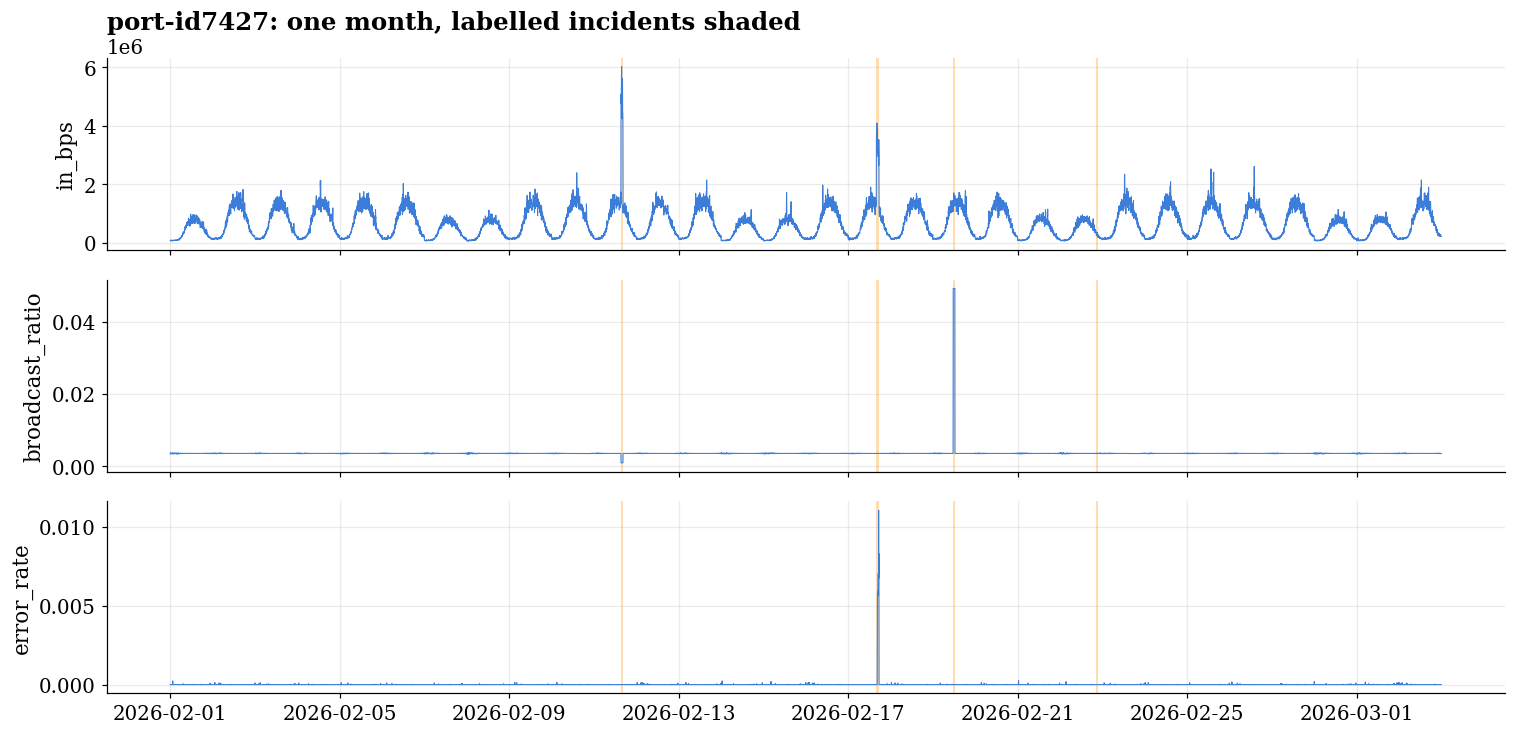

In [5]:
def shade_labelled(ax, group):
    # event_label 不是 normal 的連續段塗色。真值就是這個欄位，沒有別的來源。
    marked = group["event_label"].ne("normal").to_numpy()
    time = group["timestamp"].to_numpy()
    edges = np.flatnonzero(np.diff(marked.astype(int)))
    starts = np.r_[0, edges + 1][np.r_[marked[0], marked[edges + 1]]]
    ends = np.r_[edges, len(marked) - 1][np.r_[marked[edges], marked[-1]]]
    for a, b in zip(starts, ends):
        ax.axvspan(time[a], time[b], color=C["truth"], alpha=0.35, lw=0)


def plot_month(port_id, columns=("in_bps", "broadcast_ratio", "error_rate"), data=None):
    '''一個 port 的一整個月，事件視窗塗色。這是所有後面圖表的底圖。'''
    data = frame if data is None else data
    g = data[data["port_id"] == port_id].sort_values("timestamp")
    fig, axes = plt.subplots(len(columns), 1, figsize=(14, 2.3 * len(columns)), sharex=True)
    for ax, column in zip(np.atleast_1d(axes), columns):
        ax.plot(g["timestamp"], g[column], lw=0.7, color=C["signal"])
        shade_labelled(ax, g)
        ax.set_ylabel(column)
    np.atleast_1d(axes)[0].set_title(f"{port_id}: one month, labelled incidents shaded")
    plt.show()


plot_month("port-id7427")

橘色的窄條就是要抓的東西。第一排 `in_bps` 上有兩條看得出來，其他幾條在這個尺度下看不見，因為它們
根本沒有改變流量。第三排 `error_rate` 平常是一條貼著零的線，只有事件期間跳起來。

**一整個月只有 286 列是事件，佔 0.66%。** 這個比例是後面每一個決定的背景：在這種比例下，準確率
這種指標會被「永遠不告警」拿到 99.3 分，所以整本 notebook 一次都不會用它。

## 第 3 步　量測工具：怎麼算一個偵測器的成績

這一格是整本 notebook 的量尺，後面每一次比較都走這幾個函式。

**onset 而不是 sample。** 一段連續的告警只算一次，算在它開始的那一刻。用樣本數算，一個持續四小時
的事件會被記成 48 則告警，而一個一直黏住的偵測器會看起來比一個閃爍的還吵。

**門檻用預算訂，不用直覺訂。** Mahalanobis 距離和 IsolationForest 分數不在同一個座標軸上，只有把
誤報量對齊，兩者才可以比。每個 port 各自校準，因為五個 port 的角色差太多。

**真值是視窗，不是列。** 一個事件在一個 port 上算一個視窗，只要視窗裡有一則告警就算抓到。

In [6]:
def signal_onsets(flags):
    '''連續的告警只算一次，算在開始那一刻。'''
    flags = np.asarray(flags, bool)
    return flags & ~np.r_[False, flags[:-1]]


def calibrate_threshold(scores, target_onsets):
    '''在參考期上，讓 onset 次數最接近預算的最低門檻。平手時偏嚴格那一側。'''
    scores = np.asarray(scores, float)
    if not np.isfinite(scores).all():
        raise ValueError("calibration needs a finite score for every timestamp")
    best = None
    for candidate in np.r_[-np.inf, np.unique(scores), np.inf]:
        count = int(signal_onsets(scores > candidate).sum())
        key = (abs(count - target_onsets), count > target_onsets, -candidate)
        if best is None or key < best[0]:
            best = (key, candidate)
    return float(best[1])


def calibrate(frame, scores, reference_mask, budget=BUDGET):
    '''每個 (detector, port) 一條門檻，全部對齊同一個誤報預算。'''
    reference_mask = np.asarray(reference_mask, bool)
    out = {}
    for port, group in frame.groupby("port_id", sort=True):
        rows = group.index.to_numpy()
        keep = reference_mask[rows]
        target = int(round(budget * keep.sum() * CADENCE_S / 86400))
        for name in scores.columns:
            out[(name, port)] = calibrate_threshold(scores.loc[rows[keep], name], target)
    return out


def raise_flags(frame, scores, thresholds):
    '''每個 port 用自己的門檻，回傳一個布林表。'''
    flags = pd.DataFrame(False, index=frame.index, columns=scores.columns)
    for port, group in frame.groupby("port_id", sort=True):
        for name in scores.columns:
            flags.loc[group.index, name] = (
                scores.loc[group.index, name] > thresholds[(name, port)]).to_numpy()
    return flags

### 3b　從告警到成績

上面三個函式把分數變成告警，下面兩個把告警變成成績。分開讀：一個是決定要不要叫，一個是事後算它
叫得好不好。

In [7]:
def window_outcomes(frame, flags, windows):
    '''每個真值視窗：有沒有被抓到，以及花了多久。這是 recall 與 delay 的來源。'''
    flags = np.asarray(flags, bool)
    timestamp, port = frame["timestamp"].to_numpy(), frame["port_id"].to_numpy()
    rows = []
    for w in windows.itertuples():
        inside = ((port == w.port_id) & (timestamp >= np.datetime64(w.start))
                  & (timestamp <= np.datetime64(w.end)))
        caught = bool((flags & inside).any())
        delay = ((timestamp[flags & inside].min() - np.datetime64(w.start))
                 / np.timedelta64(1, "m")) if caught else np.nan
        rows.append({"event_id": w.event_id, "event_type": w.event_type,
                     "port_id": w.port_id, "detected": caught, "delay_min": float(delay)})
    return pd.DataFrame(rows)


def scorecard(frame, flags, windows):
    '''每個 detector 一列：視窗召回率、延遲中位數、每 port 每天的誤報 onset。'''
    timestamp, port = frame["timestamp"].to_numpy(), frame["port_id"].to_numpy()
    inside = np.zeros(len(frame), bool)
    for w in windows.itertuples():
        inside |= ((port == w.port_id) & (timestamp >= np.datetime64(w.start))
                   & (timestamp <= np.datetime64(w.end)))
    port_days = len(frame) * CADENCE_S / 86400
    rows = []
    for name in flags.columns:
        fired = flags[name].to_numpy(bool)
        got = window_outcomes(frame, fired, windows)
        false_onsets = sum(int(signal_onsets(g["_f"].to_numpy(bool)).sum())
                           for _, g in frame.assign(_f=fired & ~inside).groupby("port_id"))
        rows.append({"detector": name,
                     "event_recall": round(float(got["detected"].mean()), 3),
                     "median_delay_min": (round(float(got.loc[got["detected"],
                                                             "delay_min"].median()), 1)
                                          if got["detected"].any() else np.nan),
                     "false_per_port_day": round(false_onsets / port_days, 2)})
    return pd.DataFrame(rows).sort_values(["event_recall", "false_per_port_day"],
                                          ascending=[False, True]).reset_index(drop=True)


# 真值視窗直接用 lib.lib.anomaly_windows，Lab01 與 Lab02 用的是同一個函式。
windows = anomaly_windows(frame, events="all", ports="all")
print(f"{len(windows)} windows over {windows['event_id'].nunique()} incidents")
display(windows.head(4))

18 windows over 10 incidents


,event_id,event_type,port_id,start,end,n
0,A,business_traffic_growth,port-id7430,2026-02-04 09:00:00,2026-02-04 10:55:00,24
1,B,small_packet_scan,port-id7428,2026-02-06 13:10:00,2026-02-06 13:55:00,10
2,C,large_file_backup,port-id7431,2026-02-08 01:00:00,2026-02-08 03:55:00,36
3,D,queue_congestion,port-id7427,2026-02-11 15:20:00,2026-02-11 16:25:00,14


### 錯誤示範：用準確率來評分

上面的成績單沒有 accuracy 這一欄。先看看為什麼。

In [8]:
def accuracy_of(predictions, truth):
    return float((np.asarray(predictions, bool) == np.asarray(truth, bool)).mean())


never_alert = np.zeros(len(frame), bool)
wrong_way("一個永遠不告警的偵測器，用 accuracy 打分",
          lambda: f"accuracy {accuracy_of(never_alert, is_event):.4f}")
print(f"  它抓到的事件：{int((never_alert & is_event).sum())} / {int(is_event.sum())}")

=== 錯誤示範：一個永遠不告警的偵測器，用 accuracy 打分 ===
  沒有報錯，結果是：accuracy 0.9934
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  它抓到的事件：0 / 286


**99.34 分，抓到零個事件。**

異常佔 0.66%，所以「什麼都不做」在 accuracy 上幾乎滿分。這不是 accuracy 算錯了，是這個問題的
基礎比例讓 accuracy 沒有資訊。整本 notebook 用的是視窗召回率與每 port 每天的誤報數，因為值班表
是用這兩個數字排的。

## 第 4 步　試驗：最笨的偵測器，一條固定門檻

看一個欄位 `in_bps`，超過一條線就告警。

也要先決定哪一段資料拿來估、哪一段拿來訂門檻。fit 段估基線，calibrate 段訂門檻，兩段都先把有標記
的事件拿掉。這是 Phase I 的作法，已知的 assignable cause 要先移出參考期。**這一步有代價**，要拿掉
已知事件就得先有事件紀錄，而真實環境的紀錄通常不完整。第 13 步會量這件事有多貴。

In [9]:
FIT_END, CAL_END = pd.Timestamp("2026-02-15"), pd.Timestamp("2026-02-19")


def in_change_window(frame, calendar):
    '''這一列是不是落在公告過的變更視窗裡。scope 可能是 port，也可能是整台 device。'''
    mask = np.zeros(len(frame), bool)
    for row in calendar.itertuples():
        scope = ((frame["port_id"] == row.scope) | (frame["device_id"] == row.scope)).to_numpy()
        mask |= scope & frame["timestamp"].between(row.start_time, row.end_time).to_numpy()
    return mask


planned = in_change_window(frame, calendar)
fit_mask = (frame["timestamp"] < FIT_END).to_numpy() & ~is_event & ~planned
cal_mask = ((frame["timestamp"] >= FIT_END)
            & (frame["timestamp"] < CAL_END)).to_numpy() & ~is_event & ~planned
print(f"fit {fit_mask.sum():,} rows   calibrate {cal_mask.sum():,} rows")


def try_scores(score, label):
    '''一個分數進來，訂門檻、告警、算成績。'''
    table = pd.DataFrame({label: pd.Series(score, index=frame.index)})
    thresholds = calibrate(frame, table, cal_mask)
    return scorecard(frame, raise_flags(frame, table, thresholds), windows).iloc[0], thresholds


card, _ = try_scores(frame["in_bps"], "fixed limit")
print(f"fixed limit on in_bps    recall {card.event_recall:.3f}   "
      f"false/port/day {card.false_per_port_day:.2f}")

fit 20,059 rows   calibrate 5,692 rows
fixed limit on in_bps    recall 0.278   false/port/day 0.69


In [10]:
# 錯誤示範：門檻訂在含有事件的那段資料上
def calibrate_on(mask, label):
    table = pd.DataFrame({"fixed limit": frame["in_bps"]})
    got = scorecard(frame, raise_flags(frame, table, calibrate(frame, table, mask)),
                    windows).iloc[0]
    return f"{label}: recall {got.event_recall:.3f}, false/port/day {got.false_per_port_day:.2f}"


contaminated = ((frame["timestamp"] >= FIT_END) & (frame["timestamp"] < CAL_END)).to_numpy()
wrong_way("校準期沒有把事件拿掉", lambda: calibrate_on(contaminated, "contaminated"))
print("  " + calibrate_on(cal_mask, "clean       "))

# 你的選擇 —— BUDGET
# 上面那一格把 BUDGET 訂成每個 port 每天 0.5 次誤報。這個數字不是統計算出來的，是值班表算出來的：
# 五個 port、一天 0.5 次，等於整個 fleet 一天被打擾兩次半。把它改成 0.1 或 2.0 再跑一次這一格，
# 看 recall 跟著怎麼動。整本 notebook 的比較都建立在這個數字上，改了它，後面每一張成績單都會變。
for trial_budget in (0.1, 0.5, 2.0):
    table = pd.DataFrame({"fixed limit": frame["in_bps"]})
    got = scorecard(frame, raise_flags(frame, table,
                                       calibrate(frame, table, cal_mask, trial_budget)),
                    windows).iloc[0]
    print(f"  budget {trial_budget:<4} -> recall {got.event_recall:.3f}   "
          f"false/port/day {got.false_per_port_day:.2f}")
ladder.record(4, "fixed limit, in_bps only", "event_recall", card.event_recall,
              "misses every incident that does not change volume",
              "watch all 11 features, not one")

=== 錯誤示範：校準期沒有把事件拿掉 ===
  沒有報錯，結果是：contaminated: recall 0.278, false/port/day 0.56
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  clean       : recall 0.278, false/port/day 0.69


  budget 0.1  -> recall 0.000   false/port/day 0.00


  budget 0.5  -> recall 0.278   false/port/day 0.69
  budget 2.0  -> recall 0.500   false/port/day 1.96


{'step': 4,
 'trial': 'fixed limit, in_bps only',
 'metric': 'event_recall',
 'value': 0.278,
 'verdict': 'misses every incident that does not change volume',
 'next_step': 'watch all 11 features, not one'}

**量到 recall 0.278。** 十八個視窗只抓到五個。

**為什麼：** `in_bps` 只在流量變大時會動。broadcast storm 改變的是組成，線路品質問題改變的是錯誤
率，這些事件的 `in_bps` 幾乎不動。

**下一步：** 看十一個欄位，不要只看一個。

## 第 5 到第 7 步　試驗：基線要用什麼當鍵

每個欄位各自標準化，取最大的偏離量當分數。Lab04 把這個叫 marginal baseline。

同時試四種基線的鍵：一個全域平均、一天 24 格、平日與週末各 24 格共 48 格、一週 168 格。這座 fleet
平日的中位流量大約是週末的 1.7 倍，所以直覺上切得越細越好。

In [11]:
SEASON_KEYS = {"hour": 24, "weekend_hour": 48, "week": 168}


def season_key(timestamps, kind):
    '''季節性的分格鍵。切得越細越貼近形狀，每一格能用的樣本也越少。'''
    ts = pd.to_datetime(pd.Series(timestamps).reset_index(drop=True))
    if kind == "hour":
        return ts.dt.hour.to_numpy()
    if kind == "weekend_hour":
        return (ts.dt.dayofweek >= 5).to_numpy().astype(int) * 24 + ts.dt.hour.to_numpy()
    if kind == "week":
        return (ts.dt.dayofweek * 24 + ts.dt.hour).to_numpy()
    raise ValueError(f"unknown seasonal key {kind!r}")

In [12]:
CAP = 50.0          # 單一欄位的偏離量上限，理由見下一格的錯誤示範


def spread_of(values, robust, fallback):
    # 尺的來源，依序往下找。找不到就回 nan，代表這一格沒有尺，那一欄在這一格棄用。
    # 直接用一個像 1e-12 的地板會讓沒有尺的欄位變成分數最大的那一欄，那才是真正的災難。
    centre = np.median(values) if robust else values.mean()
    # robust 只認 MAD。MAD 是零就是「這一欄在這裡沒有 robust 的尺」，退回標準差等於自己編一把。
    candidates = ([np.median(np.abs(values - centre)) * MAD_TO_SIGMA] if robust
                  else [values.std()])
    for candidate in candidates + list(fallback):
        if candidate > 0:
            return centre, float(candidate)
    return centre, np.nan


def marginal_score(frame, features, fit_mask, kind, robust=False, cap=CAP):
    '''逐欄標準化之後取最大值。kind 是 global 或 SEASON_KEYS 裡的一個。
    每一欄的偏離量先封頂再取 max，否則一個沒有尺的欄位會蓋掉其他十欄。'''
    fit_mask = np.asarray(fit_mask, bool)
    per_feature = []
    for feature in features:
        values = frame[feature].to_numpy(float)
        out = np.zeros(len(frame))
        for _, group in frame.groupby("port_id", sort=True):
            idx = group.index.to_numpy()
            keep, x = fit_mask[idx], values[idx]
            # 整個 port 的尺，當每個 bucket 自己的尺垮掉時往上退。
            port_centre, port_scale = spread_of(x[keep], robust, [])
            if kind == "global":
                centre = np.full(len(idx), port_centre)
                scale = np.full(len(idx), port_scale)
            else:
                bucket, n = season_key(group["timestamp"], kind), SEASON_KEYS[kind]
                centre_table = np.full(n, port_centre)
                scale_table = np.full(n, port_scale)
                for b in range(n):
                    rows = keep & (bucket == b)
                    if rows.sum() >= 2:
                        centre_table[b], scale_table[b] = spread_of(
                            x[rows], robust, [] if robust else [port_scale])
                centre, scale = centre_table[bucket], scale_table[bucket]
            with np.errstate(invalid="ignore", divide="ignore"):
                out[idx] = np.abs(x - centre) / scale
        # 沒有尺的欄位是 nan，取 max 的時候略過，而不是讓它變成最大的那一個。
        per_feature.append(pd.Series(np.minimum(out, cap), index=frame.index))
    return pd.concat(per_feature, axis=1).max(axis=1, skipna=True).fillna(0.0)

In [13]:
trials = {}
for kind, label in (("global", "global"), ("hour", "hour of day"),
                    ("weekend_hour", "weekday/weekend x hour"), ("week", "hour of week")):
    score = marginal_score(frame, FEATURES, fit_mask, kind)
    card, th = try_scores(score, label)
    trials[label] = (kind, score, th, card)
    print(f"{label:26s} buckets {SEASON_KEYS.get(kind, 1):3d}   "
          f"recall {card.event_recall:.3f}   false/port/day {card.false_per_port_day:.2f}")

ladder.record(5, "marginal baseline, 11 features", "event_recall",
              trials["global"][3].event_recall,
              "recall is perfect, so recall can no longer rank anything",
              "watch the false-alert rate instead")
for step, label in ((6, "hour of day"), (7, "hour of week")):
    card = trials[label][3]
    ladder.record(step, f"baseline keyed on {label}", "false_per_port_day",
                  card.false_per_port_day,
                  f"recall still 1.000; {SEASON_KEYS[trials[label][0]]} buckets",
                  "check whether these gaps beat the noise")

global                     buckets   1   recall 1.000   false/port/day 0.76


hour of day                buckets  24   recall 1.000   false/port/day 0.53


weekday/weekend x hour     buckets  48   recall 1.000   false/port/day 0.56


hour of week               buckets 168   recall 1.000   false/port/day 0.25


In [14]:
one = frame[frame["port_id"] == "port-id7429"]
keep = fit_mask[one.index.to_numpy()]
print("samples available per bucket on the fit period:")
for kind in SEASON_KEYS:
    counts = pd.Series(season_key(one["timestamp"], kind)[keep]).value_counts()
    print(f"  {kind:14s} {SEASON_KEYS[kind]:3d} buckets   median {int(counts.median()):3d}, "
          f"min {int(counts.min()):3d}")

samples available per bucket on the fit period:
  hour            24 buckets   median 168, min 163
  weekend_hour    48 buckets   median  84, min  43
  week           168 buckets   median  24, min  19


In [15]:
BASELINE = "marginal baseline"          # 這條基線後面還會用到，名字固定下來
robust = marginal_score(frame, FEATURES, fit_mask, "hour", robust=True)
card_robust, th_robust = try_scores(robust, BASELINE)
print(f"\nrobust median/MAD, hour of day   recall {card_robust.event_recall:.3f}   "
      f"false/port/day {card_robust.false_per_port_day:.2f}")


def degenerate(frame, features, mask):
    '''robust z 分不出來的欄位：MAD 是零，或大半是零。'''
    sub = frame.loc[np.asarray(mask, bool)]
    rows = []
    for feature in features:
        x = sub[feature].to_numpy(float)
        mad = float(np.median(np.abs(x - np.median(x))))
        zero = float((x == 0).mean())
        if mad == 0 or zero > 0.5:
            rows.append({"feature": feature, "mad": mad, "zero_frac": round(zero, 3)})
    return pd.DataFrame(rows)


display(degenerate(frame, FEATURES, ~is_event))


robust median/MAD, hour of day   recall 0.944   false/port/day 0.96


,feature,mad,zero_frac
0,error_rate,0.0,0.976
1,discard_rate,0.0,0.916
2,unknown_proto_pps,0.0,0.990


In [16]:
def strict_robust_z(values):
    # 課本上的 robust z：中位數當中心，MAD 當尺。沒有任何 fallback。
    centre = np.median(values)
    return (values - centre) / (np.median(np.abs(values - centre)) * MAD_TO_SIGMA)


# 錯誤示範：沒有封頂、也沒有 fallback 的話會怎樣
# 這一個是寫這份教材時真的踩到的，而且它先騙過了成績單。
def uncapped_score(frame, features, fit_mask):
    per_feature = []
    for feature in features:
        values, out = frame[feature].to_numpy(float), np.zeros(len(frame))
        for _, group in frame.groupby("port_id", sort=True):
            idx = group.index.to_numpy()
            keep, x = fit_mask[idx], values[idx]
            bucket = season_key(group["timestamp"], "hour")
            centre_table, scale_table = np.zeros(24), np.zeros(24)
            for b in range(24):
                rows = keep & (bucket == b)
                centre_table[b] = np.median(x[rows]) if rows.any() else 0.0
                mad = np.median(np.abs(x[rows] - centre_table[b])) * MAD_TO_SIGMA if rows.any() else 0.0
                scale_table[b] = max(mad, x[rows].std() if rows.any() else 0.0, 1e-12)
            out[idx] = np.abs(x - centre_table[bucket]) / scale_table[bucket]
        per_feature.append(pd.Series(out, index=frame.index))
    return pd.concat(per_feature, axis=1).max(axis=1)


naive = uncapped_score(frame, FEATURES, fit_mask)
naive_table = pd.DataFrame({"uncapped": naive})
naive_th = calibrate(frame, naive_table, cal_mask)
naive_flags = raise_flags(frame, naive_table, naive_th)
naive_card = scorecard(frame, naive_flags, windows).iloc[0]
wrong_way("尺垮掉時用 1e-12 當地板，而且不封頂",
          lambda: f"max score {naive.max():,.0f}   成績單：recall "
                  f"{naive_card.event_recall:.3f}, false/port/day {naive_card.false_per_port_day:.2f}")
print(f"  實際的越線比例：{naive_flags['uncapped'].mean():.3f} 的樣本都在告警")
fixed_flags = raise_flags(frame, pd.DataFrame({BASELINE: robust}), th_robust)
print(f"  修好之後的越線比例：{fixed_flags[BASELINE].mean():.3f}")
print(f"  修好之後用得到的欄位：{len(FEATURES) - len(degenerate(frame, FEATURES, ~is_event))}"
      f" / {len(FEATURES)}，三個 MAD 為零的欄位在 robust 這條路上沒有尺")

wrong_way("MAD 是零的欄位，硬套 robust z",
          lambda: f"error_rate 的分數，前五個：{np.round(strict_robust_z(frame.loc[~is_event, 'error_rate'].to_numpy())[:5], 3)}")

=== 錯誤示範：尺垮掉時用 1e-12 當地板，而且不封頂 ===
  沒有報錯，結果是：max score 1,566,666,666,667   成績單：recall 1.000, false/port/day 0.44
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  實際的越線比例：0.801 的樣本都在告警
  修好之後的越線比例：0.010
  修好之後用得到的欄位：8 / 11，三個 MAD 為零的欄位在 robust 這條路上沒有尺
=== 錯誤示範：MAD 是零的欄位，硬套 robust z ===
  沒有報錯，結果是：error_rate 的分數，前五個：[nan nan nan nan nan]
  沒有報錯不代表算對了。這一種要靠你自己看出來。


'error_rate 的分數，前五個：[nan nan nan nan nan]'

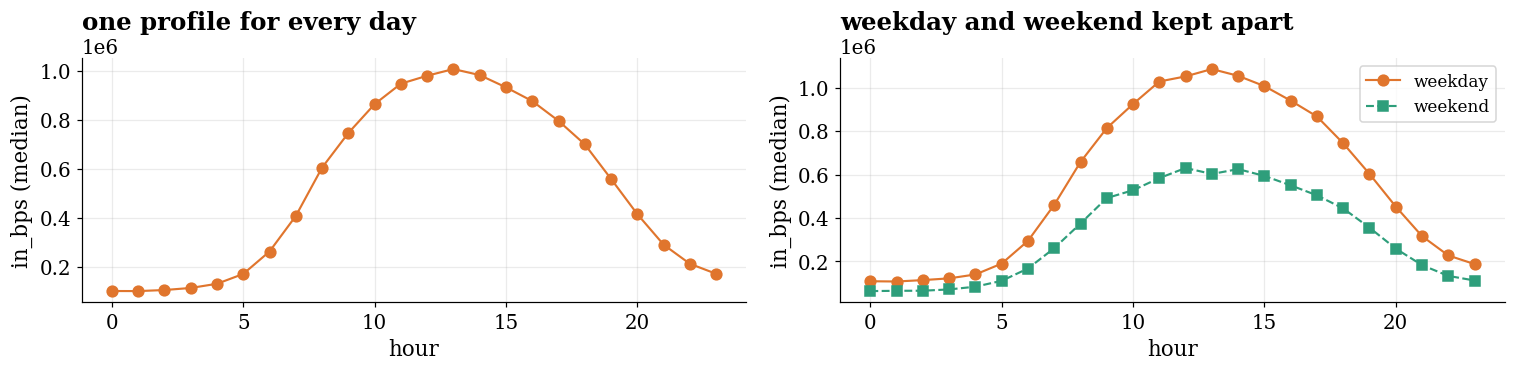

{'step': 8,
 'trial': 'robust scale, median and MAD',
 'metric': 'false_per_port_day',
 'value': 0.96,
 'verdict': '3 of 11 features have no robust scale at all, so the baseline drops to 8',
 'next_step': 'measure the uncertainty on every number so far'}

In [17]:
# 同一個 port，同一段參考期，兩種分格鍵畫出來的日內形狀
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
g = frame[(frame["port_id"] == "port-id7429") & ~is_event]
for kind, ax, label in (("hour", axes[0], "one profile for every day"),
                        ("weekend_hour", axes[1], "weekday and weekend kept apart")):
    bucket = season_key(g["timestamp"], kind)
    profile = pd.Series(g["in_bps"].to_numpy(), index=bucket).groupby(level=0).median()
    if kind == "hour":
        ax.plot(profile.index, profile.to_numpy(), "o-", color=C["baseline"])
    else:
        ax.plot(profile.index[:24], profile.to_numpy()[:24], "o-", color=C["baseline"],
                label="weekday")
        ax.plot(profile.index[:24], profile.to_numpy()[24:], "s--", color=C["peer"],
                label="weekend")
        ax.legend(fontsize=11)
    ax.set(xlabel="hour", ylabel="in_bps (median)", title=label)
plt.show()

ladder.record(8, "robust scale, median and MAD", "false_per_port_day",
              card_robust.false_per_port_day,
              "3 of 11 features have no robust scale at all, so the baseline drops to 8",
              "measure the uncertainty on every number so far")

左邊把週末和平日混在同一條曲線裡，曲線被拉平，正常帶被撐寬。右邊分開之後兩條線差了將近一倍，形狀
卻一模一樣，所以分開有道理。**但是有道理不等於比較好**，上面那幾個誤報率才是證據，而它們的排序會
隨著誤報預算改變。這一節從頭到尾只信量到的東西。

## 第 8 步　試驗：這些數字的誤差有多大

證據的單位是事件，不是樣本。整份資料只有十個事件、十八個視窗，所以要對視窗重抽。

In [18]:
def bootstrap_recall(outcomes, n_boot=2000, seed=SEED):
    '''對視窗重抽，得到 recall 的信賴區間。證據的單位是事件。'''
    detected = np.asarray(outcomes["detected"], bool)
    rng = np.random.default_rng(seed)
    draws = detected[rng.integers(0, len(detected), size=(n_boot, len(detected)))].mean(axis=1)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return {"recall": round(float(detected.mean()), 3),
            "ci95": [round(float(lo), 3), round(float(hi), 3)]}


def block_bootstrap_rate(flags, block=288, n_boot=400, seed=SEED):
    '''對連續區塊重抽，得到誤報率的區間。逐樣本重抽會打散連續段，區間會窄好幾倍。'''
    flags = np.asarray(flags, bool)
    n = len(flags)
    rng = np.random.default_rng(seed)
    rates = []
    for _ in range(n_boot):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        sample = np.concatenate([flags[s:s + block] for s in starts])[:n]
        rates.append(signal_onsets(sample).sum() / (n * CADENCE_S / 86400))
    lo, hi = np.percentile(rates, [2.5, 97.5])
    return [round(float(lo), 2), round(float(hi), 2)]


def breach_independence(flags):
    '''相鄰兩個樣本同時越線的次數，比獨立假設下的預期值高幾倍。'''
    b = np.asarray(flags, bool)
    p, n = float(b.mean()), len(b)
    observed, expected = int(np.sum(b[:-1] & b[1:])), (n - 1) * p * p
    return {"observed_adjacent": observed, "expected_if_independent": round(expected, 1),
            "ratio": round(observed / expected, 1) if expected > 0 else np.nan}


one_port = frame[frame["port_id"] == "port-id7429"].index
rows = []
for label, (kind, score, th, card) in trials.items():
    table = pd.DataFrame({label: score})
    flags_here = raise_flags(frame, table, th)
    boot = bootstrap_recall(window_outcomes(frame, flags_here[label], windows))
    rows.append({"trial": label, "recall": boot["recall"], "recall_ci": str(boot["ci95"]),
                 "false_ci_one_port": str(block_bootstrap_rate(flags_here.loc[one_port, label]))})
display(pd.DataFrame(rows))

print("adjacent-breach ratio against independence, robust hour-of-day:")
flags_robust = raise_flags(frame, pd.DataFrame({BASELINE: robust}), th_robust)
for pid, group in frame.groupby("port_id"):
    got = breach_independence(flags_robust.loc[group.index, BASELINE])
    print(f"  {pid[-4:]}  observed {got['observed_adjacent']:3d}  "
          f"expected {got['expected_if_independent']:5.1f}  ratio {got['ratio']}")
ladder.record(9, "bootstrap the scorecard", "recall_ci_width", 0.0,
              "the recall interval collapses to a point: the test is saturated",
              "make the task harder so recall can discriminate again")

,trial,recall,recall_ci,false_ci_one_port
0,global,1.0,"[1.0, 1.0]","[0.67, 1.47]"
1,hour of day,1.0,"[1.0, 1.0]","[0.93, 1.63]"
2,weekday/weekend x hour,1.0,"[1.0, 1.0]","[0.13, 0.43]"
3,hour of week,1.0,"[1.0, 1.0]","[0.13, 0.7]"


adjacent-breach ratio against independence, robust hour-of-day:
  7427  observed  58  expected   0.8  ratio 71.0
  7428  observed  49  expected   0.6  ratio 81.7
  7429  observed  36  expected   0.9  ratio 42.1
  7430  observed  67  expected   1.1  ratio 59.1
  7431  observed  69  expected   1.1  ratio 60.8


{'step': 9,
 'trial': 'bootstrap the scorecard',
 'metric': 'recall_ci_width',
 'value': 0.0,
 'verdict': 'the recall interval collapses to a point: the test is saturated',
 'next_step': 'make the task harder so recall can discriminate again'}

## 第 9 步　停手的訊號

第 5 步到第 8 步，四個非 robust 的 key 的 recall 都是 1.000，而它的區間退化成一個點。繼續調格數是在
調雜訊。robust 那一版低一些，代價是它少了三個欄位，那是尺換來的。

**這一部分到此結束，而它結束得比預期早。** 下一部分問兩件事：把題目變難之後方法會不會分出高下，
以及如果複雜的模型不能提升偵測，它們的價值在哪裡。

---
# 第二部　基礎：進階異常指標

## 第 10 步　試驗：把事件調弱

真實世界的事件不會都像資料裡這麼明顯。把每個事件視窗往它自己的 counterfactual 拉近，
counterfactual 是同一個 port、同一個時段、正常樣本的中位數。

**混合加在 raw counter 上，特徵再從 counter 重算**，所以封包數、位元組數與每一個比值之間的代數
關係都還成立。直接把特徵調弱會做出一個算術上不存在的 port。

In [19]:
def counterfactual_normal(raw, kind="weekend_hour"):
    '''每一列：這個 port 在這個時段，正常情況下每個 counter 大概是多少。'''
    bucket = season_key(raw["timestamp"], kind)
    normal = raw["event_label"].eq("normal").to_numpy()
    out = raw.copy()
    out[RAW_COLUMNS] = out[RAW_COLUMNS].astype(float)
    for _, group in raw.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        b, n = bucket[idx], normal[idx]
        for column in RAW_COLUMNS:
            x = group[column].to_numpy(float)
            table = np.full(SEASON_KEYS[kind], np.median(x[n]))
            for k in range(SEASON_KEYS[kind]):
                rows = n & (b == k)
                if rows.any():
                    table[k] = np.median(x[rows])
            out.loc[idx, column] = table[b]
    return out


def attenuate(raw, counterfactual, strength):
    '''把每個事件往 counterfactual 拉近。1.0 是原檔，0.0 是把事件抹掉。'''
    out = raw.copy()
    out[RAW_COLUMNS] = out[RAW_COLUMNS].astype(float)
    hit = raw["event_label"].ne("normal").to_numpy()
    base = counterfactual.loc[hit, RAW_COLUMNS].to_numpy(float)
    out.loc[hit, RAW_COLUMNS] = base + strength * (raw.loc[hit, RAW_COLUMNS].to_numpy(float)
                                                   - base)
    return out


counterfactual = counterfactual_normal(telemetry)
weak_frames = {s: engineer_features(attenuate(telemetry, counterfactual, s))
               for s in (1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01)}
display(pd.DataFrame({
    "strength": list(weak_frames),
    "median in_bps inside incidents": [round(float(f.loc[is_event, "in_bps"].median()))
                                       for f in weak_frames.values()]}))

,strength,median in_bps inside incidents
0,1.00,346683
1,0.50,326164
2,0.30,314840
3,0.20,313298
4,0.10,306324
5,0.05,302837
6,0.03,301442
7,0.02,300744
8,0.01,300047


## 第 11 步　試驗：多變量偵測器，以及它們撐得住多弱的事件

七個 detector，全部是前面幾節出現過的。Max |z| 是 Lab04 的 marginal baseline，Mahalanobis 與兩個
PCA 統計量是 Lab04 §4 與 §6，LOF 是 Lab02 §7 與 Lab04 §5，IsolationForest 是 Lab02 §7。

多一個 MinCovDet，Lab04 的結論把 robust covariance 列為未完成的問題，第 13 步會回答它。

模型與門檻在整個掃描中固定，唯一變動的是事件強度。

In [20]:
DETECTORS = ("Max |z|", "Mahalanobis", "Robust Mahalanobis", "PCA T2", "PCA SPE",
             "LOF", "IsolationForest")


class PortModel:
    '''一個 port 的季節輪廓、尺度，與七個 detector。只用參考期的列來配適。'''

    def __init__(self, features=FEATURES, season="weekend_hour", variance=0.95, seed=SEED):
        self.features, self.season, self.variance, self.seed = features, season, variance, seed

    def fit(self, frame, fit_mask):
        values = frame[self.features].to_numpy(float)
        bucket = season_key(frame["timestamp"], self.season)
        n = SEASON_KEYS[self.season]
        fit_mask = np.asarray(fit_mask, bool)

        self.profile_ = np.zeros((n, len(self.features)))
        overall = np.median(values[fit_mask], axis=0)
        for b in range(n):
            rows = fit_mask & (bucket == b)
            self.profile_[b] = np.median(values[rows], axis=0) if rows.any() else overall

        reference = (values - self.profile_[bucket])[fit_mask]
        mad = np.median(np.abs(reference - np.median(reference, axis=0)), axis=0) * MAD_TO_SIGMA
        self.scale_ = np.where(mad > 0, mad, reference.std(axis=0))
        self.mad_fallback_ = [f for f, m in zip(self.features, mad) if m == 0]
        if (self.scale_ <= 0).any():
            raise ValueError("a feature has no spread at all in the reference")

        z = reference / self.scale_
        self.lw_ = LedoitWolf().fit(z)
        self.mcd_ = MinCovDet(random_state=self.seed, support_fraction=0.9).fit(z)
        self.pca_ = PCA(random_state=self.seed).fit(z)
        self.k_ = int(np.searchsorted(np.cumsum(self.pca_.explained_variance_ratio_),
                                      self.variance) + 1)
        self.lof_ = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(z)
        self.iforest_ = IsolationForest(n_estimators=300, random_state=self.seed).fit(z)
        return self

    def standardize(self, frame):
        values = frame[self.features].to_numpy(float)
        bucket = season_key(frame["timestamp"], self.season)
        return (values - self.profile_[bucket]) / self.scale_

    def pca_parts(self, z):
        centred = z - self.pca_.mean_
        loadings = self.pca_.components_[:self.k_]
        projected = centred @ loadings.T
        return projected, projected @ loadings, centred, self.pca_.explained_variance_[:self.k_]

    def score_matrix(self, z):
        '''已標準化的列進來，七個分數出去。全部是越大越異常。'''
        projected, reconstruction, centred, eigenvalues = self.pca_parts(z)
        return {"Max |z|": np.abs(z).max(axis=1),
                "Mahalanobis": np.sqrt(np.clip(self.lw_.mahalanobis(z), 0, None)),
                "Robust Mahalanobis": np.sqrt(np.clip(self.mcd_.mahalanobis(z), 0, None)),
                "PCA T2": (projected ** 2 / eigenvalues).sum(axis=1),
                "PCA SPE": ((centred - reconstruction) ** 2).sum(axis=1),
                "LOF": -self.lof_.score_samples(z),
                "IsolationForest": -self.iforest_.score_samples(z)}

    def per_feature_spe(self, z):
        _, reconstruction, centred, _ = self.pca_parts(z)
        return (centred - reconstruction) ** 2

### 11b　把模型套到五個 port 上

`PortModel` 一次處理一個 port。下面兩個函式只是把它套過整座 fleet，沒有任何新的統計。

In [21]:
def fit_fleet(frame, fit_mask, season="weekend_hour"):
    fit_mask = np.asarray(fit_mask, bool)
    return {port: PortModel(season=season).fit(group.reset_index(drop=True),
                                               fit_mask[group.index.to_numpy()])
            for port, group in frame.groupby("port_id", sort=True)}


def score_fleet(frame, models):
    out = pd.DataFrame(index=frame.index, columns=list(DETECTORS), dtype=float)
    for port, group in frame.groupby("port_id", sort=True):
        local = group.reset_index(drop=True)
        for name, values in models[port].score_matrix(models[port].standardize(local)).items():
            out.loc[group.index, name] = values
    return out


# 錯誤示範：沒有先標準化就估共變異數
def condition_of(matrix):
    return float(np.linalg.cond(LedoitWolf().fit(matrix).covariance_))


raw_units = frame.loc[fit_mask, FEATURES].to_numpy(float)
one_model = PortModel().fit(frame[frame["port_id"] == "port-id7429"].reset_index(drop=True),
                            fit_mask[frame.index[frame["port_id"] == "port-id7429"]])
scaled = one_model.standardize(frame[frame["port_id"] == "port-id7429"].reset_index(drop=True))
wrong_way("in_bps 以 bit 為單位、broadcast_ratio 是 0 到 1，直接丟進同一個共變異數",
          lambda: f"condition number {condition_of(raw_units):,.0f}")
print(f"  standardised first: condition number {condition_of(scaled):,.0f}")

models = fit_fleet(frame, fit_mask)
scores = score_fleet(frame, models)
thresholds = calibrate(frame, scores, cal_mask)
flags = raise_flags(frame, scores, thresholds)
print("MAD fallback:", models["port-id7429"].mad_fallback_)
display(scorecard(frame, flags, windows))

=== 錯誤示範：in_bps 以 bit 為單位、broadcast_ratio 是 0 到 1，直接丟進同一個共變異數 ===
  沒有報錯，結果是：condition number 29,715
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  standardised first: condition number 143


MAD fallback: ['error_rate', 'discard_rate', 'unknown_proto_pps']


,detector,event_recall,median_delay_min,false_per_port_day
0,LOF,1.000,0.0,0.66
1,Max |z|,1.000,0.0,0.76
2,PCA T2,1.000,0.0,0.87
3,Mahalanobis,1.000,0.0,1.09
4,PCA SPE,1.000,0.0,1.20
5,IsolationForest,0.944,0.0,0.83
6,Robust Mahalanobis,0.944,0.0,0.99


,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest,marginal baseline
strength,,,,,,,,
1.00,1.000,1.000,0.944,1.000,1.000,1.000,0.944,0.944
0.50,1.000,1.000,0.778,1.000,1.000,1.000,0.833,0.944
0.30,1.000,1.000,0.722,1.000,1.000,1.000,0.722,0.944
0.20,1.000,1.000,0.722,1.000,0.889,1.000,0.556,1.000
0.10,1.000,1.000,0.667,1.000,0.722,1.000,0.333,1.000
0.05,0.889,0.833,0.556,0.833,0.444,0.944,0.111,1.000
0.03,0.889,0.778,0.500,0.833,0.222,0.889,0.056,0.944
0.02,0.722,0.778,0.222,0.667,0.111,0.778,0.056,0.944
0.01,0.611,0.556,0.000,0.500,0.111,0.611,0.000,0.889


,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest,marginal baseline
detection floor,0.03,0.05,1.0,0.03,0.2,0.03,0.5,0.01


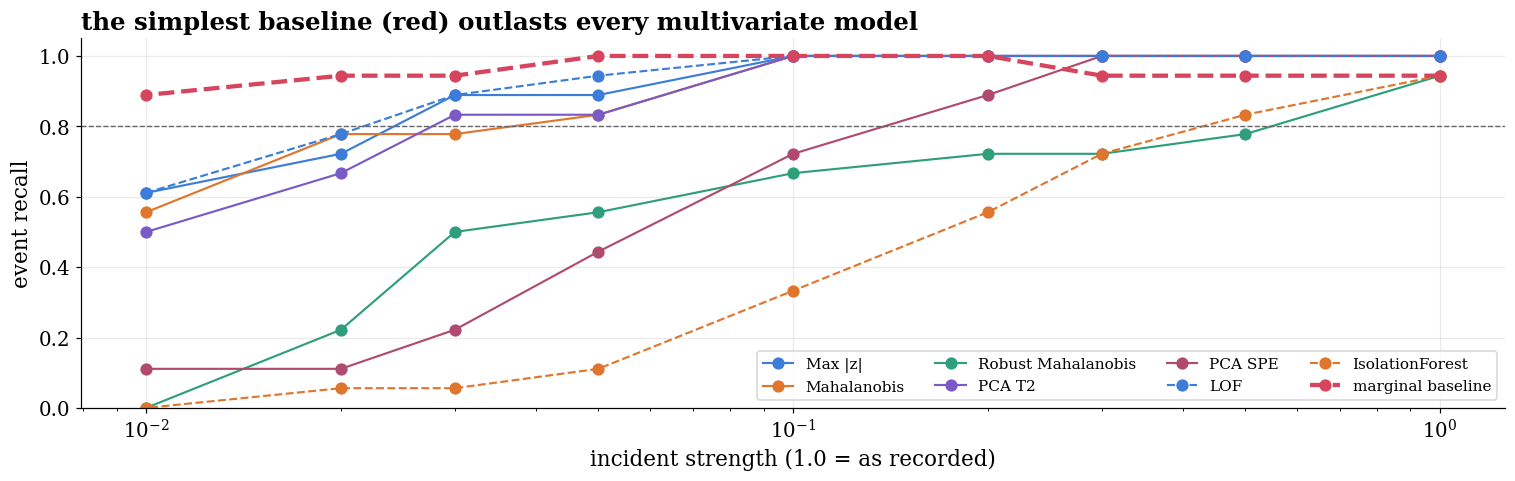

strength,recall at 0.05
Max |z|,0.889
Mahalanobis,0.833
Robust Mahalanobis,0.556
PCA T2,0.833
PCA SPE,0.444
LOF,0.944
IsolationForest,0.111
marginal baseline,1.000


{'step': 11,
 'trial': 'sweep incident strength',
 'metric': 'detection_floor',
 'value': 0.01,
 'verdict': 'the marginal baseline holds to 0.01; IsolationForest gives up at 0.5',
 'next_step': 'bootstrap the weak case before believing the ranking'}

In [22]:
rows = []
for strength, weak in weak_frames.items():
    got = scorecard(weak, raise_flags(weak, score_fleet(weak, models), thresholds),
                    windows).set_index("detector")
    row = {d: got.loc[d, "event_recall"] for d in DETECTORS}
    wb = pd.DataFrame({BASELINE: marginal_score(weak, FEATURES, fit_mask, "hour",
                                                robust=True)})
    row[BASELINE] = scorecard(weak, raise_flags(weak, wb, th_robust),
                              windows).iloc[0].event_recall
    rows.append(pd.Series(row, name=strength))
recall_by_strength = pd.DataFrame(rows)
recall_by_strength.index.name = "strength"
display(recall_by_strength)

floors = pd.Series({c: min([i for i in recall_by_strength.index
                            if recall_by_strength.loc[i, c] >= 0.8], default=np.nan)
                    for c in recall_by_strength.columns}, name="detection floor")
display(floors.to_frame().T)

fig, ax = plt.subplots(figsize=(14, 4.6))
for k, det in enumerate(recall_by_strength.columns):
    ax.plot(recall_by_strength.index, recall_by_strength[det], marker="o",
            color=C["alert"] if det == BASELINE else PORT_C[k % len(PORT_C)],
            lw=2.8 if det == BASELINE else 1.4,
            ls=["-", "--", ":"][k // len(PORT_C)], label=det)
ax.axhline(0.8, color="0.4", ls="--", lw=0.9)
ax.set(xscale="log", xlabel="incident strength (1.0 = as recorded)", ylabel="event recall",
       ylim=(0, 1.05), title="the simplest baseline (red) outlasts every multivariate model")
ax.legend(fontsize=10, ncol=4, loc="lower right")
plt.show()
# 你的選擇 —— 要用多弱的事件來比較
# 下面每一步的比較都建立在某一個強度上。0.05 是這份 notebook 的選擇，理由是它剛好讓方法分得開。
# 換成 0.2 會看到大家又都滿分，換成 0.01 會看到只剩兩個還站著。改 LOOK_AT 再跑一次下一格。
LOOK_AT = 0.05
display(recall_by_strength.loc[[LOOK_AT]].T.rename(columns={LOOK_AT: f"recall at {LOOK_AT}"}))

ladder.record(11, "sweep incident strength", "detection_floor", floors[BASELINE],
              "the marginal baseline holds to 0.01; IsolationForest gives up at 0.5",
              "bootstrap the weak case before believing the ranking")

## 第 12 步　試驗：弱事件下的排名可不可信

第 11 步排出了一個名次。在相信它之前，先做第 8 步做過的事：算區間。

In [23]:
weak = weak_frames[0.05]
weak_flags = raise_flags(weak, score_fleet(weak, models), thresholds)
rows = []
for det in DETECTORS:
    boot = bootstrap_recall(window_outcomes(weak, weak_flags[det], windows))
    rows.append({"detector": det, "recall": boot["recall"],
                 "ci95_low": boot["ci95"][0], "ci95_high": boot["ci95"][1]})
ci = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)
display(ci)
maha = ci[ci["detector"] == "Mahalanobis"].iloc[0]
ladder.record(12, "bootstrap at strength 0.05", "ci_width",
              maha["ci95_high"] - maha["ci95_low"],
              "0.833 to 0.944 overlap; the ranking is inside the interval",
              "ask what the multivariate models buy, if not recall")

,detector,recall,ci95_low,ci95_high
0,LOF,0.944,0.833,1.000
1,Max |z|,0.889,0.722,1.000
2,Mahalanobis,0.833,0.667,1.000
3,PCA T2,0.833,0.667,1.000
4,Robust Mahalanobis,0.556,0.333,0.778
5,PCA SPE,0.444,0.222,0.667
6,IsolationForest,0.111,0.000,0.278


{'step': 12,
 'trial': 'bootstrap at strength 0.05',
 'metric': 'ci_width',
 'value': 0.333,
 'verdict': '0.833 to 0.944 overlap; the ranking is inside the interval',
 'next_step': 'ask what the multivariate models buy, if not recall'}

### 那多變量模型是為了什麼

marginal baseline 的輸出是一個數字。它沒辦法回答「這個分數裡有多少是這一欄造成的」，因為它本來就
只看一欄。多變量模型的輸出可以拆，**第三部整個建立在這個能力上**。

## 第 13 步　試驗：參考期混進了事件

In [24]:
dirty_models = fit_fleet(frame, (frame["timestamp"] < FIT_END).to_numpy())
dirty_th = calibrate(frame, score_fleet(frame, dirty_models), cal_mask)
rows = []
for strength in (1.0, 0.3, 0.1, 0.05):
    weak = weak_frames[strength]
    clean = scorecard(weak, raise_flags(weak, score_fleet(weak, models), thresholds),
                      windows).set_index("detector")
    dirty = scorecard(weak, raise_flags(weak, score_fleet(weak, dirty_models), dirty_th),
                      windows).set_index("detector")
    rows.append(pd.Series({d: round(dirty.loc[d, "event_recall"]
                                    - clean.loc[d, "event_recall"], 3) for d in DETECTORS},
                          name=strength))
contamination = pd.DataFrame(rows)
contamination.index.name = "strength"
display(contamination[["Mahalanobis", "Robust Mahalanobis", "PCA T2", "PCA SPE",
                       "Max |z|", "LOF", "IsolationForest"]])
ladder.record(13, "contaminate the Phase I reference", "recall_lost_at_0.1",
              abs(contamination.loc[0.1, "Mahalanobis"]),
              "robust covariance loses 0.000 where the plain estimator loses 0.278",
              "add indicators that carry information a single score cannot")

,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,Max |z|,LOF,IsolationForest
strength,,,,,,,
1.00,0.000,-0.111,0.000,-0.111,0.000,-0.111,0.000
0.30,-0.167,0.000,-0.222,-0.222,-0.056,0.000,0.000
0.10,-0.278,0.000,-0.278,-0.166,-0.056,-0.056,0.000
0.05,-0.111,-0.056,-0.222,0.000,-0.056,-0.055,-0.055


{'step': 13,
 'trial': 'contaminate the Phase I reference',
 'metric': 'recall_lost_at_0.1',
 'value': 0.278,
 'verdict': 'robust covariance loses 0.000 where the plain estimator loses 0.278',
 'next_step': 'add indicators that carry information a single score cannot'}

參考期可信就不要買這個保險，事件紀錄不完整就值得買。
參考期可信就不要買，事件紀錄不完整就值得買。

## 第 14 到第 17 步　四種進階指標

到這裡每個指標都只看單一時刻。**下面四個各自加進一種單一時刻沒有的資訊**，而它們真正的用途要到
第三部才看得出來。

| 指標 | 加進什麼 | 分得出什麼 |
| --- | --- | --- |
| EWMA 與 CUSUM | 記憶 | 持續的偏移，對比瞬間的尖峰 |
| 一階差分 | 變化率 | 階梯式的位準改變，對比尖峰 |
| 滾動相關係數 | 欄位之間的關係 | 相關性斷裂，每一欄單獨看都正常 |
| 組成熵 | 分布形狀 | 封包種類的組成改變，與流量多寡無關 |

In [25]:
def ewma(values, lam=0.2):
    '''指數加權移動平均。lam 越小記憶越長。'''
    x = np.asarray(values, float)
    out = np.empty(len(x))
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = lam * x[i] + (1 - lam) * out[i - 1]
    return out


def cusum(values, k=0.5):
    '''單邊 CUSUM。只累積超過 k 的部分，所以雜訊不會把它推走。'''
    x = np.asarray(values, float)
    out = np.zeros(len(x))
    for i in range(1, len(x)):
        out[i] = max(0.0, out[i - 1] + x[i] - k)
    return out

In [26]:
# 兩個關係型的指標：一個看兩欄的關係，一個看組成的比例
def rolling_correlation_break(frame, a, b, fit_mask, window=72):
    '''兩欄的滾動相關係數，離它在參考期的常態有多遠。每一欄單看都可能正常。'''
    out = np.zeros(len(frame))
    for _, group in frame.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        rolling = group[a].rolling(window, min_periods=window // 2).corr(group[b])
        rolling = rolling.fillna(0.0).to_numpy()
        reference = rolling[fit_mask[idx]]
        centre = np.median(reference)
        spread = max(np.median(np.abs(reference - centre)) * MAD_TO_SIGMA, 1e-6)
        out[idx] = np.abs(rolling - centre) / spread
    return pd.Series(out, index=frame.index)


def composition_entropy(raw):
    '''封包種類組成的夏農熵。與流量多寡無關，只看比例。'''
    eps = 1e-12
    parts = pd.DataFrame({
        "ucast": raw["INUCASTPKTS"] + raw["OUTUCASTPKTS"],
        "bcast": raw["INBROADCASTPKTS"] + raw["OUTBROADCASTPKTS"],
        "mcast": raw["INMULTICASTPKTS"] + raw["OUTMULTICASTPKTS"]})
    shares = parts.div(parts.sum(axis=1) + eps, axis=0).clip(lower=eps)
    return -(shares * np.log(shares)).sum(axis=1)

In [27]:
# 上面四個算出來的東西單位都不一樣，這兩個把任何一條序列換到同一把尺上
def deviation_from_reference(values, frame, fit_mask):
    '''任何一條序列，換算成離它自己參考期常態的 robust 距離。'''
    values = pd.Series(np.asarray(values, float), index=frame.index)
    out = np.zeros(len(frame))
    for _, group in frame.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        x = values.loc[idx].to_numpy(float)
        reference = x[fit_mask[idx]]
        centre = np.median(reference)
        spread = max(np.median(np.abs(reference - centre)) * MAD_TO_SIGMA,
                     reference.std(), 1e-9)
        out[idx] = np.abs(x - centre) / spread
    return pd.Series(out, index=frame.index)


def by_port(frame, series, transform):
    '''把一個逐點的轉換套在每個 port 自己的時間序列上。'''
    values = pd.Series(np.asarray(series, float), index=frame.index)
    out = np.zeros(len(frame))
    for _, group in frame.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        out[idx] = transform(values.loc[idx].to_numpy())
    return pd.Series(out, index=frame.index)

In [28]:
def build_indicators(target_frame, target_raw):
    '''六個指標放在同一張表上，全部是越大越異常。'''
    base = score_fleet(target_frame, models)["Max |z|"]
    return pd.DataFrame({
        "instant": base,
        "EWMA memory": by_port(target_frame, base, lambda x: ewma(x, lam=0.2)),
        "CUSUM drift": by_port(target_frame, base, lambda x: cusum(x, k=0.5)),
        "jump (first difference)": by_port(target_frame, base,
                                           lambda x: np.abs(np.r_[0.0, np.diff(x)])),
        "correlation break": rolling_correlation_break(target_frame, "in_bps", "out_bps",
                                                       fit_mask),
        "composition entropy": deviation_from_reference(composition_entropy(target_raw),
                                                        target_frame, fit_mask),
    })


indicators = build_indicators(frame, telemetry)
indicator_th = calibrate(frame, indicators, cal_mask)
indicator_flags = raise_flags(frame, indicators, indicator_th)
display(scorecard(frame, indicator_flags, windows))

,detector,event_recall,median_delay_min,false_per_port_day
0,EWMA memory,1.000,0.0,0.75
1,instant,1.000,0.0,0.76
2,jump (first difference),1.000,0.0,0.92
3,composition entropy,0.889,0.0,0.94
4,CUSUM drift,0.667,0.0,0.14
5,correlation break,0.000,NaN,0.45


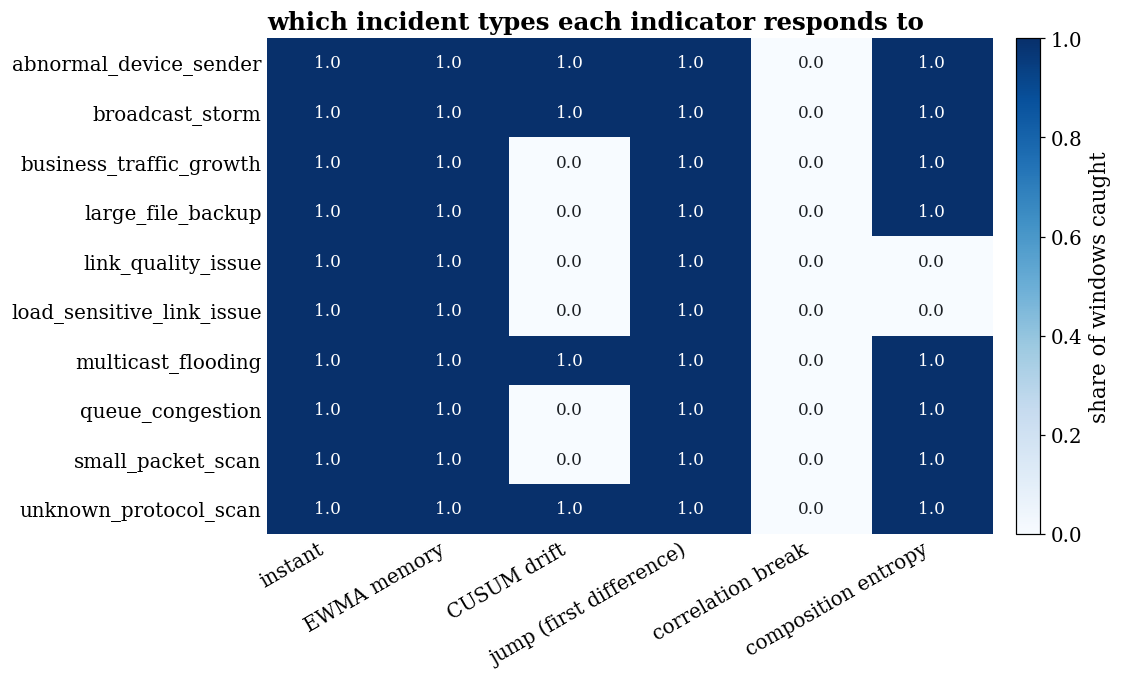

,event_recall,median_delay_min,false_per_port_day
detector,,,
EWMA memory,0.944,0.0,0.73
instant,0.889,0.0,0.76
jump (first difference),0.889,0.0,0.90
composition entropy,0.778,0.0,0.94
CUSUM drift,0.444,0.0,0.08
correlation break,0.000,NaN,0.39


{'step': 17,
 'trial': 'four temporal and relational indicators',
 'metric': 'event_recall_at_0.05',
 'value': 0.944,
 'verdict': 'EWMA memory survives attenuation best; each indicator sees a different subset',
 'next_step': 'carry the per-feature decomposition into root cause'}

In [29]:
# 每個指標各自對哪些故障種類有反應。這才是它們的用處：不是誰的 recall 高，
# 是誰看得見別人看不見的。
rows = []
for name in indicators.columns:
    got = window_outcomes(frame, indicator_flags[name], windows)
    rows.append(pd.Series(got.groupby("event_type")["detected"].mean(), name=name))
coverage = pd.DataFrame(rows).fillna(0.0)
heatmap(coverage.T, fmt="{:.1f}", cbar_label="share of windows caught",
        title="which incident types each indicator responds to")

weak_ind = build_indicators(weak_frames[0.05], attenuate(telemetry, counterfactual, 0.05))
weak_card = scorecard(weak_frames[0.05], raise_flags(weak_frames[0.05], weak_ind, indicator_th),
                      windows).set_index("detector")
display(weak_card)
best = weak_card["event_recall"].idxmax()
ladder.record(17, "four temporal and relational indicators", "event_recall_at_0.05",
              weak_card.loc[best, "event_recall"],
              f"{best} survives attenuation best; each indicator sees a different subset",
              "carry the per-feature decomposition into root cause")

## 第 18 步　讀出來的東西

在偵測上這些指標沒有價值，第 5 步已經全部抓到了。在根因上它們價值很大，第 30 步會把「觸發了哪幾個
指標」變成可以評分的東西。

---
# 第三部　承重：根因分析

偵測回答「有沒有事」。工程師收到告警之後要回答的是另外幾個問題，而前面五節沒有量過任何一個。

| 問題 | 量法 | 真值 |
| --- | --- | --- |
| 哪一個 counter 在動 | attribution hit@k | `FAULT_SIGNATURE`，由事件描述寫成 |
| 影響到哪些 port，誰先動 | localization、onset ordering | telemetry 的 `event_id` 與 `port_id` |
| 這是哪一種故障 | cause typing | `event_type` |
| 證據夠不夠下結論 | evidence sufficiency | 前兩名候選的差距 |
| 這是不是我們自己排的 | suppression | `change_calendar.csv` |

`FAULT_SIGNATURE` 從事件描述寫成，不是從資料擬合的。用同一份資料推出來的真值表去評分歸因，量到的
是自己的假設。表和資料不一致時，那是關於其中一方的發現，不是回頭改表的理由。

## 第 19 步　真值表，以及亂猜的水準

In [30]:
FAULT_SIGNATURE = {
    "business_traffic_growth":   {"in_bps", "out_bps", "in_pps", "out_pps"},
    "small_packet_scan":         {"avg_pkt_bytes", "in_pps", "out_pps"},
    "large_file_backup":         {"avg_pkt_bytes", "in_bps", "out_bps"},
    "queue_congestion":          {"discard_rate", "in_bps", "out_bps"},
    "link_quality_issue":        {"error_rate"},
    "load_sensitive_link_issue": {"error_rate", "in_bps", "out_bps"},
    "broadcast_storm":           {"broadcast_ratio"},
    "multicast_flooding":        {"multicast_ratio"},
    "abnormal_device_sender":    {"tx_ratio", "out_bps", "out_pps"},
    "unknown_protocol_scan":     {"unknown_proto_pps"},
}


def random_baseline(k=1, features=FEATURES):
    '''亂猜的 hit@k。有這條線，一張命中率的表才知道要贏過什麼。'''
    rates = []
    for signature in FAULT_SIGNATURE.values():
        present = len(signature & set(features))
        miss = 1.0
        for i in range(k):
            miss *= max(len(features) - present - i, 0) / max(len(features) - i, 1)
        rates.append(1 - miss)
    return round(float(np.mean(rates)), 3)


CHANCE = random_baseline(1)
print(f"random top-1 pick scores hit@1 {CHANCE}, hit@3 {random_baseline(3)}")
display(pd.Series({k: ", ".join(sorted(v)) for k, v in FAULT_SIGNATURE.items()}
                  ).to_frame("signature counters"))

random top-1 pick scores hit@1 0.209, hit@3 0.518


,signature counters
business_traffic_growth,"in_bps, in_pps, out_bps, out_pps"
small_packet_scan,"avg_pkt_bytes, in_pps, out_pps"
large_file_backup,"avg_pkt_bytes, in_bps, out_bps"
queue_congestion,"discard_rate, in_bps, out_bps"
link_quality_issue,error_rate
load_sensitive_link_issue,"error_rate, in_bps, out_bps"
broadcast_storm,broadcast_ratio
multicast_flooding,multicast_ratio
abnormal_device_sender,"out_bps, out_pps, tx_ratio"
unknown_protocol_scan,unknown_proto_pps


## 第 20 步　試驗：最直覺的歸因，哪一欄的偏離最大

In [31]:
DETECTOR = "Mahalanobis"


def peak_row(frame, scores, window, detector=DETECTOR):
    '''一個視窗裡分數最高的那一列。歸因都在這一列上做。'''
    idx = frame.index[(frame["port_id"] == window.port_id)
                      & frame["timestamp"].between(window.start, window.end)]
    return idx, scores.loc[idx, detector].idxmax()


def share(values):
    total = float(np.sum(values))
    return np.asarray(values, float) / total if total > 0 else np.full(len(values), np.nan)


def score_one(model, z_row, detector=DETECTOR):
    '''單獨一列的分數，歸因要靠它反覆重算。'''
    z = np.asarray(z_row, float).reshape(1, -1)
    return float(model.score_matrix(z)[detector][0])

In [32]:
# 第一種歸因，以及量所有歸因方法用的同一套流程
def attribution_absz(model, z_row, spe_row):
    '''R0：每一欄的偏離量佔多少。最直覺，也最容易被比值的分母騙。'''
    return pd.Series(share(np.abs(z_row)), index=FEATURES)


def attribute(model, frame, scores, window, method):
    '''在視窗的峰值那一列上，跑一種歸因方法。'''
    idx, peak = peak_row(frame, scores, window)
    local = frame.loc[idx].reset_index(drop=True)
    z_all = model.standardize(local)
    position = list(idx).index(peak)
    return method(model, z_all[position], model.per_feature_spe(z_all)[position])


def attribution_scoreboard(methods, frame, scores, models, windows):
    '''每個歸因方法在十八個視窗上的 hit@1 與 hit@3。'''
    rows = []
    for w in windows.itertuples():
        row = {"event_id": w.event_id, "event_type": w.event_type, "port": w.port_id[-4:]}
        for name, method in methods.items():
            ranked = attribute(models[w.port_id], frame, scores, w,
                               method).sort_values(ascending=False)
            row[f"{name} top1"] = ranked.index[0]
            for k in (1, 3):
                row[f"{name} hit@{k}"] = bool(set(ranked.index[:k])
                                              & FAULT_SIGNATURE[w.event_type])
        rows.append(row)
    return pd.DataFrame(rows)


def summarise(table, methods):
    return pd.DataFrame([{"attribution": name,
                          "hit@1": round(float(table[f"{name} hit@1"].mean()), 3),
                          "hit@3": round(float(table[f"{name} hit@3"].mean()), 3)}
                         for name in methods]).sort_values(
                             "hit@1", ascending=False).reset_index(drop=True)

In [33]:
# 錯誤示範：對 marginal baseline 做歸因
# 它的分數就是「最大的那一維」，所以任何歸因都只會把 100% 給那一維。這不是解釋，
# 這是把 argmax 重講一次。第 11 步說多變量模型的價值在可以拆解，指的就是這件事。
w_demo = windows[windows["event_id"] == "A"].iloc[0]
idx_demo, peak_demo = peak_row(frame, scores, w_demo)
z_demo = models[w_demo.port_id].standardize(
    frame.loc[idx_demo].reset_index(drop=True))[list(idx_demo).index(peak_demo)]


def baseline_attribution(z_row):
    contribution = np.zeros(len(FEATURES))
    contribution[int(np.argmax(np.abs(z_row)))] = 1.0
    return pd.Series(contribution, index=FEATURES)


wrong_way("把 max |z| 當成可以拆解的分數",
          lambda: dict(baseline_attribution(z_demo)[baseline_attribution(z_demo) > 0]))

methods = {"R0 max |z|": attribution_absz}
table = attribution_scoreboard(methods, frame, scores, models, windows)
display(table[["event_id", "event_type", "port", "R0 max |z| top1", "R0 max |z| hit@1"]])
r0 = summarise(table, methods)
display(r0)
ladder.record(20, "attribution: largest |z|", "hit@1", r0["hit@1"].iloc[0],
              "0.889, and both failures share one mechanism",
              "look at what the two failures have in common")

=== 錯誤示範：把 max |z| 當成可以拆解的分數 ===
  沒有報錯，結果是：{'multicast_ratio': np.float64(1.0)}
  沒有報錯不代表算對了。這一種要靠你自己看出來。


,event_id,event_type,port,R0 max |z| top1,R0 max |z| hit@1
0,A,business_traffic_growth,7430,multicast_ratio,False
1,B,small_packet_scan,7428,out_pps,True
2,C,large_file_backup,7431,multicast_ratio,False
3,D,queue_congestion,7427,discard_rate,True
4,E,link_quality_issue,7429,error_rate,True
5,F,load_sensitive_link_issue,7427,error_rate,True
6,G,broadcast_storm,7431,broadcast_ratio,True
7,G,broadcast_storm,7430,broadcast_ratio,True
8,G,broadcast_storm,7429,broadcast_ratio,True
9,G,broadcast_storm,7428,broadcast_ratio,True


,attribution,hit@1,hit@3
0,R0 max |z|,0.889,1.0


{'step': 20,
 'trial': 'attribution: largest |z|',
 'metric': 'hit@1',
 'value': 0.889,
 'verdict': '0.889, and both failures share one mechanism',
 'next_step': 'look at what the two failures have in common'}

## 第 21 步　診斷：比值的分母在動

every window R0 got wrong:


,event_id,event_type,port,R0 max |z| top1
0,A,business_traffic_growth,7430,multicast_ratio
2,C,large_file_backup,7431,multicast_ratio



event A, business_traffic_growth, at its peak on port-id7430:


,at the peak,normal median,times normal
in_pps,200.083333,35.553333,5.63
out_pps,93.493333,19.903333,4.70
multicast_ratio,0.002577,0.004878,0.53
broadcast_ratio,0.001476,0.002787,0.53


,at the peak,normal median,times normal
INMULTICASTPKTS,134,48.0,2.79
OUTMULTICASTPKTS,93,33.0,2.82
INUCASTPKTS,59779,10578.0,5.65
OUTUCASTPKTS,27831,5892.5,4.72


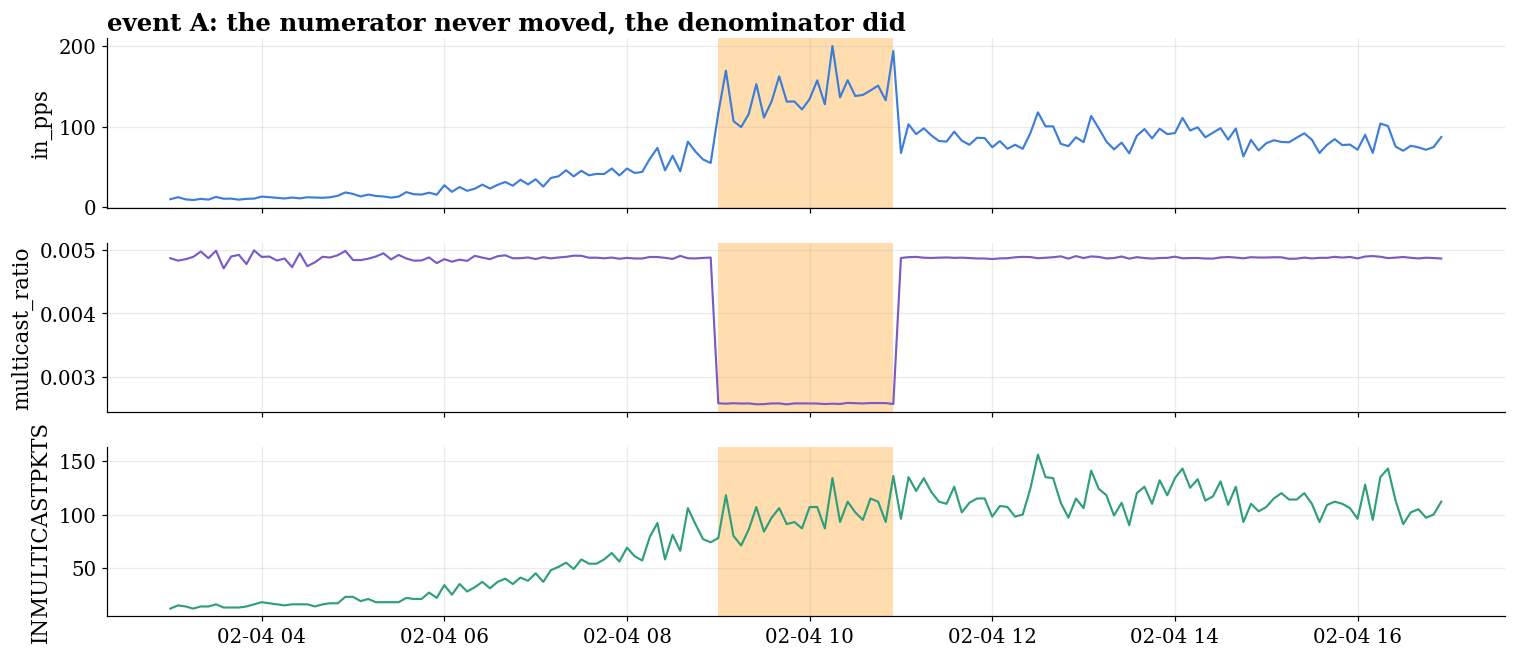

In [34]:
print("every window R0 got wrong:")
display(table[~table["R0 max |z| hit@1"]][["event_id", "event_type", "port", "R0 max |z| top1"]])

w = windows[windows["event_id"] == "A"].iloc[0]
idx, peak = peak_row(frame, scores, w)
reference = frame[(frame["port_id"] == w.port_id) & ~is_event]
show = ["in_pps", "out_pps", "multicast_ratio", "broadcast_ratio"]
compare = pd.DataFrame({"at the peak": frame.loc[peak, show],
                        "normal median": reference[show].median()})
compare["times normal"] = (compare["at the peak"] / compare["normal median"]).round(2)
print(f"\nevent A, business_traffic_growth, at its peak on {w.port_id}:")
display(compare)
counts = ["INMULTICASTPKTS", "OUTMULTICASTPKTS", "INUCASTPKTS", "OUTUCASTPKTS"]
raw_compare = pd.DataFrame({"at the peak": telemetry.loc[peak, counts],
                            "normal median": telemetry.loc[reference.index, counts].median()})
raw_compare["times normal"] = (raw_compare["at the peak"]
                               / raw_compare["normal median"]).round(2)
display(raw_compare)

# 把分子與分母畫在一起，比值的假象就看得見了。
g = frame[frame["port_id"] == w.port_id]
window_slice = g["timestamp"].between(w.start - pd.Timedelta(hours=6),
                                      w.end + pd.Timedelta(hours=6))
fig, axes = plt.subplots(3, 1, figsize=(14, 6.2), sharex=True)
for ax, column, colour in ((axes[0], "in_pps", C["signal"]),
                           (axes[1], "multicast_ratio", C["score"]),
                           (axes[2], "INMULTICASTPKTS", C["peer"])):
    series = (g.loc[window_slice, column] if column in g
              else telemetry.loc[g.index[window_slice], column])
    ax.plot(g.loc[window_slice, "timestamp"], series, lw=1.4, color=colour)
    ax.axvspan(w.start, w.end, color=C["truth"], alpha=0.35, lw=0)
    ax.set_ylabel(column)
axes[0].set_title("event A: the numerator never moved, the denominator did")
plt.show()

兩個錯的視窗，A 與 C，都是這個機制。**下一步：** 換一個不會被分母騙的歸因方式，先試最省事的。

## 第 22 到第 23 步　試驗與診斷：免費的拆解

In [35]:
def attribution_spe(model, z_row, spe_row):
    '''R1：PCA 重建誤差的逐欄拆解。免費，因為可加的分數會自己拆開。'''
    return pd.Series(share(spe_row), index=FEATURES)


methods["R1 PCA SPE share"] = attribution_spe
table = attribution_scoreboard(methods, frame, scores, models, windows)
display(summarise(table, methods))
print("what R1 named, across all 18 windows:")
display(table["R1 PCA SPE share top1"].value_counts().to_frame("windows"))

shape = pd.DataFrame([{"feature": f,
                       "excess_kurtosis": round(float(stats.kurtosis(
                           frame.loc[fit_mask, f].to_numpy())), 1),
                       "zero_frac": round(float((frame[f] == 0).mean()), 3)}
                      for f in FEATURES]).sort_values("excess_kurtosis", ascending=False)
display(shape.head(5))
ladder.record(22, "attribution: free PCA SPE split", "hit@1",
              summarise(table, methods).query(
                  "attribution == 'R1 PCA SPE share'")["hit@1"].iloc[0],
              f"0.278, barely above the {CHANCE} chance floor",
              "find which feature is eating the sum")

,attribution,hit@1,hit@3
0,R0 max |z|,0.889,1.000
1,R1 PCA SPE share,0.278,0.389


what R1 named, across all 18 windows:


,windows
R1 PCA SPE share top1,
error_rate,13
avg_pkt_bytes,2
discard_rate,2
tx_ratio,1


,feature,excess_kurtosis,zero_frac
7,error_rate,235.2,0.976
8,discard_rate,179.0,0.913
9,unknown_proto_pps,106.1,0.990
3,out_pps,6.2,0.000
1,out_bps,5.3,0.000


{'step': 22,
 'trial': 'attribution: free PCA SPE split',
 'metric': 'hit@1',
 'value': 0.278,
 'verdict': '0.278, barely above the 0.209 chance floor',
 'next_step': 'find which feature is eating the sum'}

**下一步：** 不要用分數的內部結構，直接用擾動去問。

## 第 24 到第 25 步　試驗與診斷：把一欄拉回正常

In [36]:
def attribution_leave_one_out(model, z_row, spe_row):
    '''R2：把第 j 欄換回季節正常值，分數掉多少就算它的貢獻。'''
    base = score_one(model, z_row)
    drops = []
    for j in range(len(FEATURES)):
        perturbed = np.array(z_row, float)
        perturbed[j] = 0.0
        drops.append(max(base - score_one(model, perturbed), 0.0))
    return pd.Series(share(drops), index=FEATURES)


methods["R2 leave-one-out"] = attribution_leave_one_out
table = attribution_scoreboard(methods, frame, scores, models, windows)
display(summarise(table, methods))

model = models["port-id7430"]
w = windows[windows["event_id"] == "A"].iloc[0]
idx, peak = peak_row(frame, scores, w)
local = frame.loc[idx].reset_index(drop=True)
z_row = model.standardize(local)[list(idx).index(peak)]
print("event A: in_pps and out_pps moved together, and they are correlated")
print(f"their correlation on the reference period: "
      f"{frame.loc[fit_mask, ['in_pps', 'out_pps']].corr().iloc[0, 1]:.3f}")
display(pd.DataFrame({"|z| at the peak": np.abs(z_row),
                      "R2 leave-one-out": attribution_leave_one_out(model, z_row, None)},
                     index=FEATURES).sort_values("|z| at the peak", ascending=False).head(5))
ladder.record(24, "attribution: leave-one-out", "hit@1",
              summarise(table, methods).query(
                  "attribution == 'R2 leave-one-out'")["hit@1"].iloc[0],
              "0.778, correlated counters cancel each other out",
              "ask what each feature keeps, not what it removes")

,attribution,hit@1,hit@3
0,R0 max |z|,0.889,1.000
1,R2 leave-one-out,0.778,0.889
2,R1 PCA SPE share,0.278,0.389


event A: in_pps and out_pps moved together, and they are correlated
their correlation on the reference period: 0.662


,|z| at the peak,R2 leave-one-out
multicast_ratio,93.058748,0.675509
broadcast_ratio,50.788081,0.324491
in_bps,29.845616,0.000000
in_pps,29.134347,0.000000
out_pps,19.064648,0.000000


{'step': 24,
 'trial': 'attribution: leave-one-out',
 'metric': 'hit@1',
 'value': 0.778,
 'verdict': '0.778, correlated counters cancel each other out',
 'next_step': 'ask what each feature keeps, not what it removes'}

## 第 26 步　修正：只有這一欄偏離的話，分數還剩多少

,attribution,hit@1,hit@3
0,R3 counterfactual,0.944,1.000
1,R0 max |z|,0.889,1.000
2,R2 leave-one-out,0.778,0.889
3,R1 PCA SPE share,0.278,0.389


,event_id,event_type,port,R0 max |z| top1,R3 counterfactual top1
0,A,business_traffic_growth,7430,multicast_ratio,in_pps
1,B,small_packet_scan,7428,out_pps,out_pps
2,C,large_file_backup,7431,multicast_ratio,multicast_ratio
3,D,queue_congestion,7427,discard_rate,discard_rate
4,E,link_quality_issue,7429,error_rate,error_rate
5,F,load_sensitive_link_issue,7427,error_rate,error_rate
6,G,broadcast_storm,7431,broadcast_ratio,broadcast_ratio
7,G,broadcast_storm,7430,broadcast_ratio,broadcast_ratio


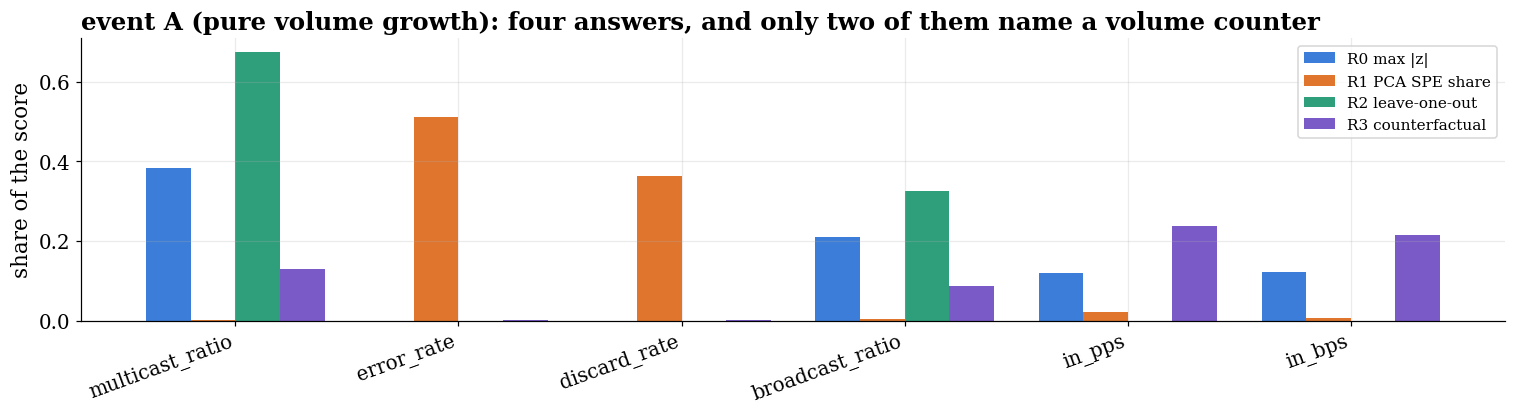

{'step': 26,
 'trial': 'attribution: counterfactual',
 'metric': 'hit@1',
 'value': 0.944,
 'verdict': '0.944, and it fixes the ratio artefact from step 21',
 'next_step': 'try pairs, for the faults that live in a relationship'}

In [37]:
def attribution_counterfactual(model, z_row, spe_row):
    '''R3：只留下第 j 欄，其他全部歸零，分數還剩多少。相關的兩欄不會互相抵銷。'''
    kept = []
    for j in range(len(FEATURES)):
        alone = np.zeros(len(FEATURES))
        alone[j] = z_row[j]
        kept.append(max(score_one(model, alone), 0.0))
    return pd.Series(share(kept), index=FEATURES)


methods["R3 counterfactual"] = attribution_counterfactual
table = attribution_scoreboard(methods, frame, scores, models, windows)
summary = summarise(table, methods)
display(summary)
display(table[["event_id", "event_type", "port",
               "R0 max |z| top1", "R3 counterfactual top1"]].head(8))
compare_methods = pd.DataFrame({
    name: attribute(models["port-id7430"], frame, scores,
                    windows[windows["event_id"] == "A"].iloc[0], method)
    for name, method in methods.items()})
top = compare_methods.max(axis=1).sort_values(ascending=False).head(6).index
fig, ax = plt.subplots(figsize=(14, 4.0))
width = 0.2
for k, name in enumerate(methods):
    ax.bar(np.arange(len(top)) + (k - 1.5) * width, compare_methods.loc[top, name],
           width=width, label=name, color=PORT_C[k % len(PORT_C)])
ax.set_xticks(np.arange(len(top)), top, rotation=20, ha="right")
ax.set(ylabel="share of the score", title="event A (pure volume growth): four answers, "
       "and only two of them name a volume counter")
ax.legend(fontsize=10)
plt.show()

ladder.record(26, "attribution: counterfactual", "hit@1",
              summary.query("attribution == 'R3 counterfactual'")["hit@1"].iloc[0],
              "0.944, and it fixes the ratio artefact from step 21",
              "try pairs, for the faults that live in a relationship")

## 第 27 步　試驗：成對歸因

前面四個方法都假設「原因是某一欄」。有些故障不是這樣，它是兩欄之間的關係壞掉，而兩欄各自都還在
正常帶裡面。第 16 步的 correlation break 指標就是為這種事準備的。

成對歸因問的是：只留下第 j 與第 k 欄，分數剩多少，而這個數字比兩欄各自單獨留下來的最大值高多少。
高出來的部分就是這一對的交互作用。

In [38]:
def pair_interaction(model, z_row, top=5):
    '''只留下一對欄位的分數，減掉兩欄各自單獨的較大值。剩下的是這一對的交互作用。'''
    alone = {}
    for j in range(len(FEATURES)):
        v = np.zeros(len(FEATURES))
        v[j] = z_row[j]
        alone[j] = score_one(model, v)
    ranked = sorted(alone, key=alone.get, reverse=True)[:top]
    rows = []
    for a in range(len(ranked)):
        for b in range(a + 1, len(ranked)):
            j, k = ranked[a], ranked[b]
            v = np.zeros(len(FEATURES))
            v[j], v[k] = z_row[j], z_row[k]
            joint = score_one(model, v)
            rows.append({"pair": f"{FEATURES[j]} + {FEATURES[k]}", "joint": round(joint, 1),
                         "best_alone": round(max(alone[j], alone[k]), 1),
                         "interaction": round(joint - max(alone[j], alone[k]), 1)})
    return pd.DataFrame(rows).sort_values("interaction", ascending=False).reset_index(drop=True)


rows = []
for w in windows.drop_duplicates("event_id").itertuples():
    idx, peak = peak_row(frame, scores, w)
    local = frame.loc[idx].reset_index(drop=True)
    z_row = models[w.port_id].standardize(local)[list(idx).index(peak)]
    best = pair_interaction(models[w.port_id], z_row).iloc[0]
    rows.append({"event_id": w.event_id, "event_type": w.event_type,
                 "strongest pair": best["pair"], "interaction": best["interaction"],
                 "joint": best["joint"],
                 "pair_dominated": bool(best["interaction"] > 0.5 * best["joint"])})
pairs = pd.DataFrame(rows)
display(pairs)
ladder.record(27, "attribution: pair interaction", "share_pair_dominated",
              float(pairs["pair_dominated"].mean()),
              "reports whether a fault lives in one counter or in a relationship",
              "turn the named counter into a named fault type")

,event_id,event_type,strongest pair,interaction,joint,pair_dominated
0,A,business_traffic_growth,in_bps + out_pps,41.4,105.9,False
1,B,small_packet_scan,in_pps + out_bps,37.3,491.3,False
2,C,large_file_backup,multicast_ratio + avg_pkt_bytes,10.6,75.0,False
3,D,queue_congestion,in_pps + out_bps,98.7,212.2,False
4,E,link_quality_issue,in_bps + in_pps,1.5,4.6,False
5,F,load_sensitive_link_issue,out_bps + out_pps,14.0,58.1,False
6,G,broadcast_storm,broadcast_ratio + discard_rate,9.0,878.6,False
7,H,multicast_flooding,multicast_ratio + discard_rate,57.6,1034.7,False
8,I,abnormal_device_sender,out_pps + in_bps,20.2,360.9,False
9,J,unknown_protocol_scan,in_pps + out_bps,11.9,130.8,False


{'step': 27,
 'trial': 'attribution: pair interaction',
 'metric': 'share_pair_dominated',
 'value': 0.0,
 'verdict': 'reports whether a fault lives in one counter or in a relationship',
 'next_step': 'turn the named counter into a named fault type'}

`interaction` 相對於 `joint` 很小，表示這個故障確實是單一欄位造成的，看那一欄就夠了。兩者接近，
表示要同時看兩欄才解釋得了，單欄的歸因會漏掉一半。

這一欄不會改善 hit@1，它回答的是另一個問題：**這份歸因可不可以只講一個 counter。**

## 第 28 到第 29 步　試驗與修正：從 counter 到故障種類

In [39]:
def type_by_set_match(shares, k=3):
    '''最直覺的作法：前 k 名跟 signature 取交集，比 Jaccard。'''
    top = set(shares.sort_values(ascending=False).index[:k])
    scored = [(len(top & sig) / len(top | sig), name)
              for name, sig in sorted(FAULT_SIGNATURE.items())]
    best = max(scored)
    return best[1] if best[0] > 0 else "unclassified"


def type_scores(shares, floor=0.05):
    '''每一種故障的分數：coverage 乘 specificity。
    coverage 是份額落在 signature 上的比例，specificity 是 signature 裡真的動了的欄位比例。
    只看 coverage，signature 大的種類會靠包含關係贏；只看集合交集，單欄 signature 會平手。'''
    scored = []
    for name, signature in sorted(FAULT_SIGNATURE.items()):
        present = [f for f in signature if f in shares.index]
        if not present:
            continue
        coverage = float(shares[present].sum())
        specificity = float(np.mean([shares[f] >= floor for f in present]))
        scored.append({"type": name, "score": round(coverage * specificity, 3)})
    return pd.DataFrame(scored).sort_values("score", ascending=False).reset_index(drop=True)


def type_by_mass(shares):
    ranked = type_scores(shares)
    return ranked["type"].iloc[0] if ranked["score"].iloc[0] > 0 else "unclassified"

,event_id,true_type,set match,mass x specificity,set match ok,mass x specificity ok
0,A,business_traffic_growth,business_traffic_growth,business_traffic_growth,True,True
1,B,small_packet_scan,business_traffic_growth,small_packet_scan,False,True
2,C,large_file_backup,multicast_flooding,multicast_flooding,False,False
3,D,queue_congestion,queue_congestion,business_traffic_growth,True,False
4,E,link_quality_issue,small_packet_scan,link_quality_issue,False,True
5,F,load_sensitive_link_issue,load_sensitive_link_issue,link_quality_issue,True,False
6,G,broadcast_storm,multicast_flooding,broadcast_storm,False,True
7,G,broadcast_storm,multicast_flooding,broadcast_storm,False,True
8,G,broadcast_storm,multicast_flooding,broadcast_storm,False,True
9,G,broadcast_storm,queue_congestion,broadcast_storm,False,True


set matching        0.556
mass x specificity  0.833

event G attribution shares, which set matching threw away:


,share
broadcast_ratio,0.863
discard_rate,0.087
multicast_ratio,0.023
in_pps,0.012


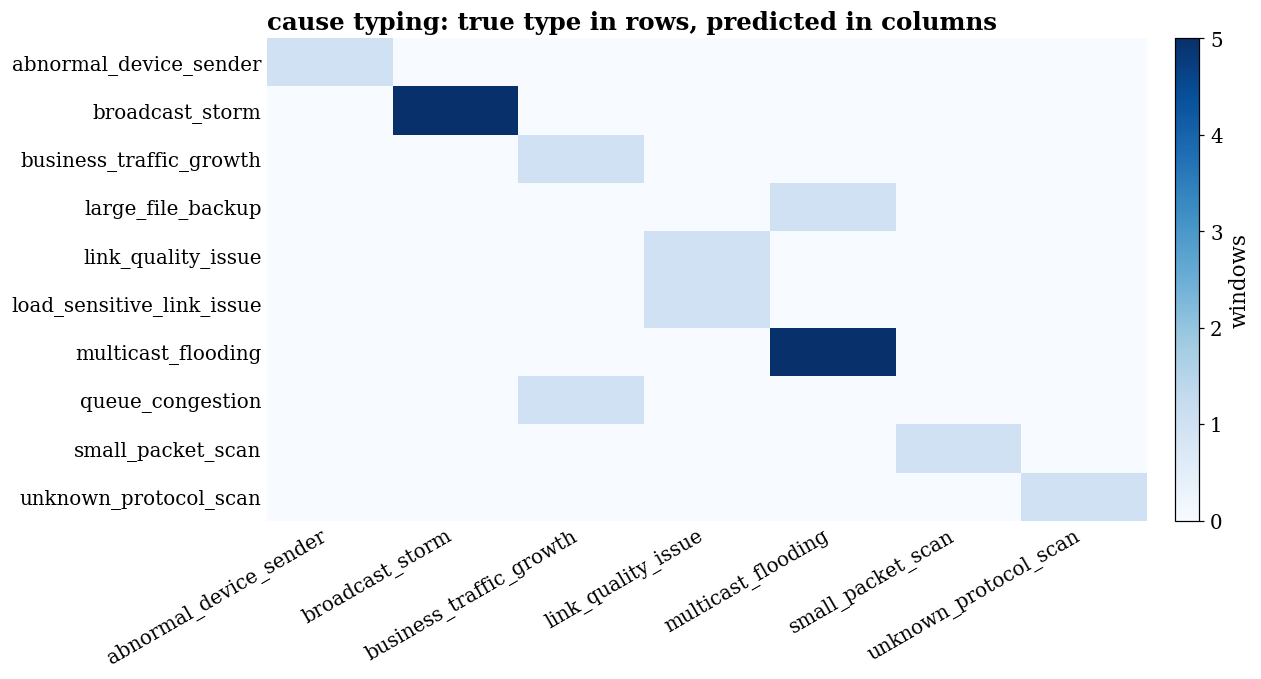

{'step': 29,
 'trial': 'cause typing by mass and specificity',
 'metric': 'type_accuracy',
 'value': 0.8333,
 'verdict': 'the residual errors are genuine disagreements with the table',
 'next_step': 'add a second, independent axis of evidence'}

In [40]:
# 同樣十八個視窗，同一套歸因份額，兩種判型方式各判一次
rows = []
for w in windows.itertuples():
    shares = attribute(models[w.port_id], frame, scores, w, attribution_counterfactual)
    rows.append({"event_id": w.event_id, "true_type": w.event_type,
                 "set match": type_by_set_match(shares),
                 "mass x specificity": type_by_mass(shares)})
typing = pd.DataFrame(rows)
for column in ("set match", "mass x specificity"):
    typing[f"{column} ok"] = typing[column] == typing["true_type"]
display(typing)
print(f"set matching        {typing['set match ok'].mean():.3f}")
print(f"mass x specificity  {typing['mass x specificity ok'].mean():.3f}")

storm = windows[windows["event_id"] == "G"].iloc[0]
shares = attribute(models[storm.port_id], frame, scores, storm, attribution_counterfactual)
print("\nevent G attribution shares, which set matching threw away:")
display(shares.sort_values(ascending=False).head(4).round(3).to_frame("share"))

heatmap(pd.crosstab(typing["true_type"], typing["mass x specificity"]),
        fmt="{:.0f}", cbar_label="windows",
        title="cause typing: true type in rows, predicted in columns")
ladder.record(28, "cause typing by set matching", "type_accuracy",
              typing["set match ok"].mean(),
              "single-counter signatures tie and the tie breaks on sort order",
              "weight by attributed mass and by specificity")
ladder.record(29, "cause typing by mass and specificity", "type_accuracy",
              typing["mass x specificity ok"].mean(),
              "the residual errors are genuine disagreements with the table",
              "add a second, independent axis of evidence")

剩下的錯誤是真的：load sensitive link issue 的 signature 包含 link quality issue 的，兩者的差別是
當時流量高不高，單一樣本的偏離量分不出來。**光看哪一欄在動不夠，需要另一個軸的證據。**

## 第 30 步　試驗：時間形狀當第二個證據軸

同樣是錯誤率上升，一次瞬間的尖峰和一段持續的高原是不同的故障。第 14 到 17 步做的那些指標就是為了
分這個，現在把它變成可以評分的東西。

shape,plateau,ramp
event_type,,
abnormal_device_sender,1,0
broadcast_storm,5,0
business_traffic_growth,1,0
large_file_backup,1,0
link_quality_issue,1,0
load_sensitive_link_issue,0,1
multicast_flooding,4,1
queue_congestion,0,1
small_packet_scan,1,0


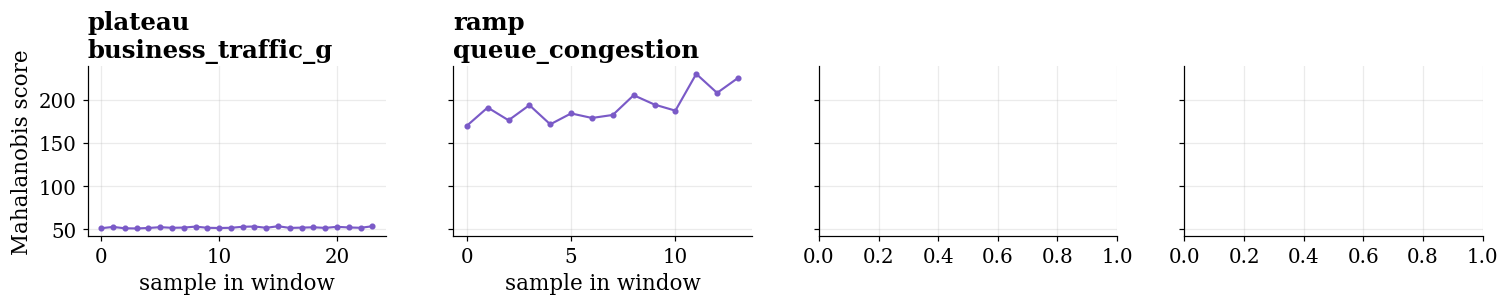

,dominant shape share
event_type,
abnormal_device_sender,1.0
broadcast_storm,1.0
business_traffic_growth,1.0
large_file_backup,1.0
link_quality_issue,1.0
load_sensitive_link_issue,1.0
multicast_flooding,0.8
queue_congestion,1.0
small_packet_scan,1.0


{'step': 30,
 'trial': 'temporal shape as a second axis',
 'metric': 'shape_consistency',
 'value': 0.98,
 'verdict': 'each incident type keeps a stable shape, so shape is usable evidence',
 'next_step': 'widen from one port to the blast radius'}

In [41]:
def temporal_shape(series):
    '''一段分數序列是尖峰、階梯還是斜坡。三個特徵決定：尖峰佔比、前後半差、單調性。'''
    x = np.asarray(series, float)
    if len(x) < 4 or x.max() <= 0:
        return "flat"
    peak_share = float(x.max() / (x.sum() + 1e-9))
    first, second = x[:len(x) // 2].mean(), x[len(x) // 2:].mean()
    step = float(abs(second - first) / (abs(first) + abs(second) + 1e-9))
    monotone = float(np.corrcoef(np.arange(len(x)), x)[0, 1])
    if peak_share > 0.45:
        return "spike"
    if abs(monotone) > 0.7:
        return "ramp"
    if step > 0.35:
        return "step"
    return "plateau"


rows = []
for w in windows.itertuples():
    idx, _ = peak_row(frame, scores, w)
    rows.append({"event_id": w.event_id, "event_type": w.event_type, "port": w.port_id[-4:],
                 "samples": len(idx),
                 "shape": temporal_shape(scores.loc[idx, DETECTOR].to_numpy())})
shapes = pd.DataFrame(rows)
display(pd.crosstab(shapes["event_type"], shapes["shape"]))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.0), sharey=True)
examples = shapes.drop_duplicates("shape").head(4)
for ax, row in zip(axes, examples.itertuples()):
    w = windows[windows["event_id"] == row.event_id].iloc[0]
    idx, _ = peak_row(frame, scores, w)
    ax.plot(np.arange(len(idx)), scores.loc[idx, DETECTOR].to_numpy(), "o-",
            color=C["score"], ms=3)
    ax.set(title=f"{row.shape}\n{row.event_type[:18]}", xlabel="sample in window")
axes[0].set_ylabel(f"{DETECTOR} score")
plt.show()

# 一種故障如果總是同一個形狀，形狀就是可用的證據。
consistency = shapes.groupby("event_type")["shape"].agg(
    lambda s: s.value_counts().iloc[0] / len(s))
display(consistency.round(2).to_frame("dominant shape share"))
ladder.record(30, "temporal shape as a second axis", "shape_consistency",
              float(consistency.mean()),
              "each incident type keeps a stable shape, so shape is usable evidence",
              "widen from one port to the blast radius")

## 第 31 步　試驗：影響範圍，以及誰先動

十個事件裡有兩個的 scope 是 MULTI，broadcast storm 與 multicast flooding，同時出現在五個 port 上。
分辨單埠故障與全機事件是 RCA 最有價值的判斷之一，前者派人去看那張卡，後者要往上游查。

**再多問一個問題：誰先動。** 如果五個 port 依序亮起來，最先亮的通常離源頭最近。這是唯一能從
telemetry 讀出因果方向的線索。

,event_id,event_type,ports_true,ports_fired,missed,spurious,jaccard,called_common_mode,is_common_mode
0,A,business_traffic_growth,1,2,0,1,0.500,False,False
1,B,small_packet_scan,1,1,0,0,1.000,False,False
2,C,large_file_backup,1,3,0,2,0.333,True,False
3,D,queue_congestion,1,1,0,0,1.000,False,False
4,E,link_quality_issue,1,1,0,0,1.000,False,False
5,F,load_sensitive_link_issue,1,1,0,0,1.000,False,False
6,G,broadcast_storm,5,5,0,0,1.000,True,True
7,H,multicast_flooding,5,5,0,0,1.000,True,True
8,I,abnormal_device_sender,1,2,0,1,0.500,False,False
9,J,unknown_protocol_scan,1,1,0,0,1.000,False,False


mean jaccard 0.833   common-mode accuracy 0.900


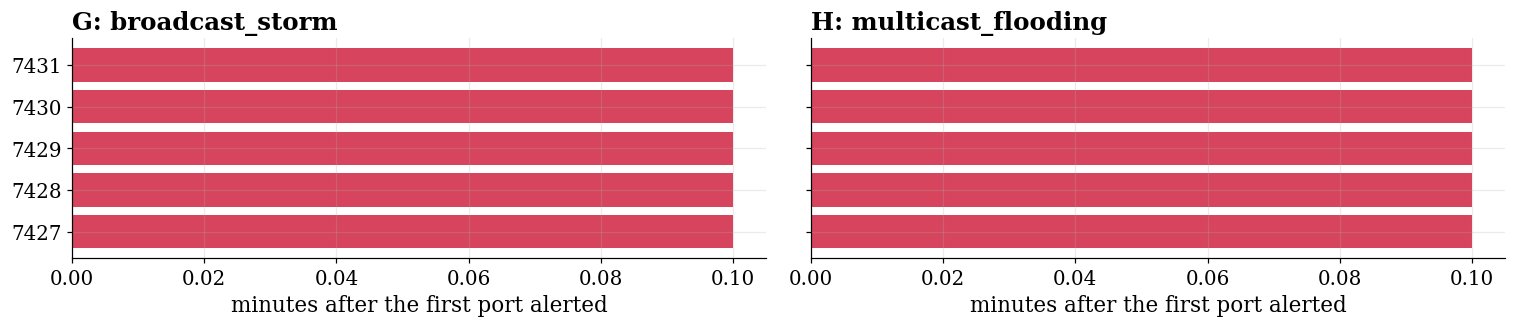

onset order for G:


,port_id,first_alert,lag_min
0,port-id7427,2026-02-19 11:30:00,0.0
1,port-id7428,2026-02-19 11:30:00,0.0
2,port-id7429,2026-02-19 11:30:00,0.0
3,port-id7430,2026-02-19 11:30:00,0.0
4,port-id7431,2026-02-19 11:30:00,0.0


onset order for H:


,port_id,first_alert,lag_min
0,port-id7427,2026-02-22 20:05:00,0.0
1,port-id7428,2026-02-22 20:05:00,0.0
2,port-id7429,2026-02-22 20:05:00,0.0
3,port-id7430,2026-02-22 20:05:00,0.0
4,port-id7431,2026-02-22 20:05:00,0.0


{'step': 31,
 'trial': 'localization and onset ordering',
 'metric': 'mean_jaccard',
 'value': 0.8333,
 'verdict': 'both MULTI events resolved exactly; the onset order gives a lead port',
 'next_step': 'ask whether the evidence can separate the top two candidates'}

In [42]:
def localization(frame, flags, windows):
    '''報出來的 port 對不對，有沒有漏，有沒有多。'''
    flags = np.asarray(flags, bool)
    n_ports = frame["port_id"].nunique()
    rows = []
    for event_id, group in windows.groupby("event_id"):
        truth = set(group["port_id"])
        span = frame["timestamp"].between(group["start"].min(), group["end"].max()).to_numpy()
        fired = set(frame.loc[span & flags, "port_id"].unique())
        rows.append({"event_id": event_id, "event_type": group["event_type"].iloc[0],
                     "ports_true": len(truth), "ports_fired": len(fired),
                     "missed": len(truth - fired), "spurious": len(fired - truth),
                     "jaccard": round(len(truth & fired) / max(len(truth | fired), 1), 3),
                     "called_common_mode": len(fired) >= 0.6 * n_ports,
                     "is_common_mode": len(truth) >= 0.6 * n_ports})
    return pd.DataFrame(rows)


def onset_order(frame, flags, windows, event_id):
    '''這個事件在每個 port 上第一次告警的時刻。排序之後就是傳播順序。'''
    flags = np.asarray(flags, bool)
    group = windows[windows["event_id"] == event_id]
    span = frame["timestamp"].between(group["start"].min(), group["end"].max()).to_numpy()
    hit = frame[span & flags]
    if hit.empty:
        return pd.DataFrame(columns=["port_id", "first_alert", "lag_min"])
    out = (hit.groupby("port_id", as_index=False)["timestamp"].min()
              .rename(columns={"timestamp": "first_alert"})
              .sort_values("first_alert").reset_index(drop=True))
    out["lag_min"] = (out["first_alert"] - out["first_alert"].min()).dt.total_seconds() / 60
    return out


local = localization(frame, flags[DETECTOR], windows)
display(local)
print(f"mean jaccard {local['jaccard'].mean():.3f}   common-mode accuracy "
      f"{(local['called_common_mode'] == local['is_common_mode']).mean():.3f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 3.2), sharey=True)
for ax, event_id in zip(axes, ("G", "H")):
    order = onset_order(frame, flags[DETECTOR], windows, event_id)
    ax.barh(np.arange(len(order)), order["lag_min"].clip(lower=0.1), color=C["alert"])
    ax.set_yticks(np.arange(len(order)), [p[-4:] for p in order["port_id"]])
    ax.invert_yaxis()
    ax.set(xlabel="minutes after the first port alerted",
           title=f"{event_id}: {windows[windows.event_id == event_id].event_type.iloc[0]}")
plt.show()
for event_id in ("G", "H"):
    print(f"onset order for {event_id}:")
    display(onset_order(frame, flags[DETECTOR], windows, event_id))
ladder.record(31, "localization and onset ordering", "mean_jaccard",
              float(local["jaccard"].mean()),
              "both MULTI events resolved exactly; the onset order gives a lead port",
              "ask whether the evidence can separate the top two candidates")

## 第 32 步　試驗：證據夠不夠下結論

前面每一步都在提高準確率。這一步問的是另一件事：**什麼時候應該承認分不出來。**

把第 29 步的種類分數取前兩名，如果差距很小，那就是證據不足，硬報一個名字只是把不確定性藏起來。

In [43]:
def evidence_sufficient(shares, margin=0.15):
    '''前兩名差距夠大才算分得出來。'''
    ranked = type_scores(shares)
    gap = float(ranked["score"].iloc[0] - ranked["score"].iloc[1])
    return {"top": ranked["type"].iloc[0], "runner_up": ranked["type"].iloc[1],
            "gap": round(gap, 3), "separable": bool(gap >= margin)}


rows = []
for w in windows.itertuples():
    shares = attribute(models[w.port_id], frame, scores, w, attribution_counterfactual)
    got = evidence_sufficient(shares)
    rows.append({"event_id": w.event_id, "true_type": w.event_type, **got,
                 "top_correct": got["top"] == w.event_type})
sufficiency = pd.DataFrame(rows)
display(sufficiency)
separable = sufficiency[sufficiency["separable"]]
unclear = sufficiency[~sufficiency["separable"]]
print(f"separable windows        {len(separable)}/{len(sufficiency)}")
print(f"accuracy when separable  {separable['top_correct'].mean():.3f}")
print(f"accuracy when not        "
      f"{unclear['top_correct'].mean() if len(unclear) else float('nan'):.3f}")
# 你的選擇 —— margin
# 0.15 決定了什麼叫「分得出來」。訂高一點，敢下結論的次數變少而那些結論更準；訂低一點，反過來。
# 這是把多少不確定性推給人的旋鈕，不是統計問題。
for trial_margin in (0.05, 0.15, 0.40):
    got = pd.DataFrame([evidence_sufficient(
        attribute(models[w.port_id], frame, scores, w, attribution_counterfactual),
        margin=trial_margin) | {"true": w.event_type} for w in windows.itertuples()])
    ok = got[got["separable"]]
    print(f"  margin {trial_margin:<5} separable {len(ok):2d}/18   "
          f"accuracy there {(ok['top'] == ok['true']).mean() if len(ok) else float('nan'):.3f}")

ladder.record(32, "evidence sufficiency", "accuracy_when_separable",
              float(separable["top_correct"].mean()),
              "declaring 'cannot separate' beats a confident wrong name",
              "separate a real fault from an announced change")

,event_id,true_type,top,runner_up,gap,separable,top_correct
0,A,business_traffic_growth,business_traffic_growth,small_packet_scan,0.494,True,True
1,B,small_packet_scan,small_packet_scan,business_traffic_growth,0.126,False,True
2,C,large_file_backup,multicast_flooding,large_file_backup,0.037,False,False
3,D,queue_congestion,business_traffic_growth,queue_congestion,0.004,False,False
4,E,link_quality_issue,link_quality_issue,load_sensitive_link_issue,0.658,True,True
5,F,load_sensitive_link_issue,link_quality_issue,load_sensitive_link_issue,0.224,True,False
6,G,broadcast_storm,broadcast_storm,queue_congestion,0.833,True,True
7,G,broadcast_storm,broadcast_storm,queue_congestion,0.831,True,True
8,G,broadcast_storm,broadcast_storm,abnormal_device_sender,0.908,True,True
9,G,broadcast_storm,broadcast_storm,queue_congestion,0.745,True,True


separable windows        14/18
accuracy when separable  0.929
accuracy when not        0.500


  margin 0.05  separable 16/18   accuracy there 0.938


  margin 0.15  separable 14/18   accuracy there 0.929


  margin 0.4   separable 13/18   accuracy there 1.000


{'step': 32,
 'trial': 'evidence sufficiency',
 'metric': 'accuracy_when_separable',
 'value': 0.9286,
 'verdict': "declaring 'cannot separate' beats a confident wrong name",
 'next_step': 'separate a real fault from an announced change'}

## 第 33 步　試驗：這是不是我們自己排的

In [44]:
def announced_events(frame, windows, planned, threshold=0.5):
    '''一半以上的樣本落在公告視窗裡，就算這個事件是公告過的。'''
    out = []
    for w in windows.itertuples():
        mask = ((frame["port_id"] == w.port_id)
                & frame["timestamp"].between(w.start, w.end)).to_numpy()
        if mask.sum() and (planned & mask).sum() / mask.sum() >= threshold:
            out.append(w.event_id)
    return sorted(set(out))


def suppression(frame, flags, windows, planned):
    '''套上行事曆之後，公告過的還在不在叫，真故障有沒有一起被消音。'''
    flags = np.asarray(flags, bool)
    announced = set(announced_events(frame, windows, planned))
    rows = []
    for name, active in (("no calendar", flags), ("calendar applied", flags & ~planned)):
        got = window_outcomes(frame, active, windows)
        got["announced"] = got["event_id"].isin(announced)
        real = got[~got["announced"]]
        rows.append({"arm": name,
                     "real_faults_caught": f"{int(real['detected'].sum())}/{len(real)}",
                     "announced_still_alerting": int(got.loc[got["announced"],
                                                             "detected"].sum()),
                     "alert_samples": int(active.sum())})
    return pd.DataFrame(rows), announced


table_supp, announced = suppression(frame, flags[DETECTOR], windows, planned)
display(table_supp)
print("announced incidents:", announced)
display(calendar[["change_id", "change_type", "scope", "start_time", "description"]])
ladder.record(33, "suppress announced changes", "real_faults_kept", 1.0,
              "both announced incidents silenced, no real fault lost",
              "pack the evidence and hand it to a language model")

,arm,real_faults_caught,announced_still_alerting,alert_samples
0,no calendar,16/16,2,459
1,calendar applied,16/16,0,398


announced incidents: {'C', 'A'}


,change_id,change_type,scope,start_time,description
0,CH-01,scheduled_backup,port-id7431,2026-02-08 00:50:00,週日夜間全量備份至異地儲存
1,CH-02,business_change,port-id7430,2026-02-04 08:50:00,新業務系統上線導流至 office VLAN
2,CH-03,maintenance,core-sw-01,2026-02-16 02:00:00,核心交換器韌體升級維護視窗
3,CH-04,maintenance,edge-fw-01,2026-02-21 03:00:00,邊界防火牆規則批次更新


{'step': 33,
 'trial': 'suppress announced changes',
 'metric': 'real_faults_kept',
 'value': 1.0,
 'verdict': 'both announced incidents silenced, no real fault lost',
 'next_step': 'pack the evidence and hand it to a language model'}

---
# 第四部　解讀：LLM 與人的迴圈

## 第 34 步　把證據裝成 packet

這份資料有 43,200 列。就算模型吃得下，它也沒辦法算 Mahalanobis 距離、沒辦法做 counterfactual 歸因、
沒辦法知道正常帶有多寬。前面三十三步做的每一件事，模型都做不到。

**所以模型拿到的是 packet，不是資料。** 每一個欄位都是工具算出來的，模型的工作是排序、陳述、指出還
缺什麼證據。`ground_truth_type` 不會跨過這條界線。

In [45]:
def build_packet(event_id, port_id):
    '''一則事件壓成模型可以讀的結構。每個欄位都是前面某一步算出來的。'''
    w = windows[(windows["event_id"] == event_id) & (windows["port_id"] == port_id)].iloc[0]
    idx, peak = peak_row(frame, scores, w)
    model = models[port_id]
    shares = attribute(model, frame, scores, w, attribution_counterfactual)
    ranked = shares.sort_values(ascending=False)
    row = frame.loc[peak]
    reference = frame[(frame["port_id"] == port_id) & (frame["timestamp"] < w.start)].tail(288)

    span = frame["timestamp"].between(w.start, w.end).to_numpy()
    peers = []
    for port, group in frame.groupby("port_id", sort=True):
        if port == port_id:
            continue
        rows = group.index[span[group.index]]
        peers.append(bool(len(rows)
                          and scores.loc[rows, DETECTOR].max() > thresholds[(DETECTOR, port)]))
    change = calendar[(calendar["start_time"] <= row["timestamp"])
                      & (calendar["end_time"] >= row["timestamp"])
                      & ((calendar["scope"] == port_id)
                         | (calendar["scope"] == row["device_id"]))]
    verdict = evidence_sufficient(shares)
    indicator_row = indicators.loc[peak]
    return {
        "device_id": str(row["device_id"]), "port_id": str(port_id),
        "port_role": str(row["port_role"]), "window_start": str(w.start),
        "duration_min": int((w.end - w.start).total_seconds() / 60) + 5,
        "detector": DETECTOR, "score": round(float(scores.loc[peak, DETECTOR]), 1),
        "threshold": round(float(thresholds[(DETECTOR, port_id)]), 1),
        "score_over_threshold": round(float(scores.loc[peak, DETECTOR])
                                      / max(thresholds[(DETECTOR, port_id)], 1e-9), 1),
        "attribution_top3": {k: round(float(v), 3) for k, v in ranked.head(3).items()},
        "measured_at_peak": {f: round(float(row[f]), 4) for f in ranked.head(3).index},
        "normal_median": {f: round(float(reference[f].median()), 4)
                          for f in ranked.head(3).index},
        "temporal_shape": temporal_shape(scores.loc[idx, DETECTOR].to_numpy()),
        "indicators_at_peak": {k: round(float(indicator_row[k]), 1)
                               for k in ("EWMA memory", "CUSUM drift",
                                         "jump (first difference)", "correlation break",
                                         "composition entropy")},
        "peer_ports_deviating": int(sum(peers)), "peer_ports_total": len(peers),
        "planned_change": (str(change["change_id"].iloc[0]) if len(change) else ""),
        "candidate_type": verdict["top"], "runner_up_type": verdict["runner_up"],
        "candidate_margin": verdict["gap"], "evidence_separable": verdict["separable"],
        "ground_truth_type": str(w.event_type),
    }


packet = build_packet("G", "port-id7429")
print(json.dumps(packet, ensure_ascii=False, indent=2))

{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1457.4,
  "threshold": 10.8,
  "score_over_threshold": 134.7,
  "attribution_top3": {
    "broadcast_ratio": 0.908,
    "discard_rate": 0.047,
    "multicast_ratio": 0.029
  },
  "measured_at_peak": {
    "broadcast_ratio": 0.0387,
    "discard_rate": 0.0015,
    "multicast_ratio": 0.0038
  },
  "normal_median": {
    "broadcast_ratio": 0.0028,
    "discard_rate": 0.0,
    "multicast_ratio": 0.0049
  },
  "temporal_shape": "plateau",
  "indicators_at_peak": {
    "EWMA memory": 3213.8,
    "CUSUM drift": 62875.1,
    "jump (first difference)": 0.8,
    "correlation break": 0.1,
    "composition entropy": 893.4
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_change": "",
  "candidate_type": "broadcast_storm",
  "runner_up_type": "abnormal_device_sender",
  "candidate_margin"

## 第 35 步　第一輪：把 prompt 貼進 LLM

下一格印出一段 prompt。**把兩條線之間的全部內容複製，貼進你的 LLM 聊天視窗。**

prompt 裡有一份工具清單。模型只能要求清單上的東西，這條規則由 notebook 這邊強制執行，不是靠模型
自律。模型應該會回一段 `ACTION: TOOL`。把**整段回覆**貼進下一格的 `PASTE_ROUND_1`。

In [46]:
TOOLS = {
    "get_recent_metrics": "Recent measured values for one port over a stated window.",
    "check_related_devices": "Whether other ports deviated over the same window.",
    "check_change_calendar": "Whether an announced change covers this port and time.",
    "get_onset_order": "Which port alerted first during this incident.",
}

SYSTEM_PROMPT = (
    "You are a network incident investigator. Evidence is supplied by monitoring tools. "
    "Use only the values in the packet and the tool results. Never invent a number. "
    "Cite the packet field behind every claim. If the packet cannot distinguish a real fault "
    "from an announced change, say so. No action executes without human approval.")


def reply_contract():
    '''回覆格式。嚴格到可以解析，鬆到可以手打。'''
    return ("Reply in exactly this format, nothing before or after.\n\n"
            "To request evidence:\n"
            "THOUGHT: <one line on what you still need and why>\n"
            "ACTION: TOOL\n"
            "TOOL: <one tool name from the list>\n"
            "INPUT: <a single-line JSON object of that tool's arguments>\n\n"
            "To conclude:\n"
            "THOUGHT: <one line>\n"
            "ACTION: REPORT\n"
            "CAUSE: <one sentence>\n"
            f"TYPE: <exactly one of: {', '.join(sorted(FAULT_SIGNATURE))}>\n"
            "CONFIDENCE: <low | medium | high>\n"
            "EVIDENCE: <one sentence citing packet fields in brackets such as [score]>\n"
            "RUNNER_UP: <one sentence, and why the evidence does not settle it>\n"
            "NEXT_CHECK: <the one measurement that would separate them>\n"
            "ESCALATE: <yes | no>")


def redacted(packet):
    '''答案不會跨過這條界線，否則是在評模型會不會抄答案。'''
    return {k: v for k, v in packet.items() if k != "ground_truth_type"}


def build_prompt(packet, transcript=()):
    listed = "\n".join(f"  {name}: {what}" for name, what in TOOLS.items())
    history = "\n".join(
        f"\nYOU ASKED: {s['tool']} with {json.dumps(s['input'], ensure_ascii=False)}"
        f"\nTOOL ANSWERED: {json.dumps(s['output'], ensure_ascii=False)}" for s in transcript)
    return (SYSTEM_PROMPT + "\n\nYou may call these tools, and nothing else:\n" + listed
            + "\n\nEVIDENCE PACKET:\n"
            + json.dumps(redacted(packet), ensure_ascii=False, indent=2)
            + "\n\nEVIDENCE GATHERED SO FAR:" + (history or "\n(nothing yet)")
            + "\n\nAsk for the single piece of evidence that would most change your "
              "conclusion, or report now.\n\n" + reply_contract())

### 35b　工具的實作

上面決定模型看得到什麼，下面決定它問得到什麼。**這是整份 notebook 唯一需要換掉才能上線的地方**，
把下面四個分支指向真的 Prometheus 查詢即可，上面的 prompt 與後面的評分都不用動。

In [47]:
def call_tool(name, payload):
    '''工具的實作。指向真的 Prometheus 就是這份 notebook 搬進 production 的全部工作。'''
    if name not in TOOLS:
        raise ValueError(f"{name} is not a declared tool: {sorted(TOOLS)}")
    if name == "get_recent_metrics":
        until = pd.Timestamp(payload["until"])
        minutes = payload.get("minutes", 60)
        rows = frame[(frame["port_id"] == payload["port_id"])
                     & (frame["timestamp"] > until - pd.Timedelta(minutes=minutes))
                     & (frame["timestamp"] <= until)]
        if rows.empty:
            return {"samples": 0}
        return {"samples": int(len(rows)),
                **{f: round(float(rows[f].max()), 4) for f in FEATURES[:7]}}
    if name == "check_related_devices":
        span = frame["timestamp"].between(pd.Timestamp(payload["start"]),
                                          pd.Timestamp(payload["end"])).to_numpy()
        out = []
        for port, group in frame.groupby("port_id", sort=True):
            if port == payload.get("exclude_port_id"):
                continue
            rows = group.index[span[group.index]]
            out.append({"port_id": port,
                        "deviating": bool(len(rows) and scores.loc[rows, DETECTOR].max()
                                          > thresholds[(DETECTOR, port)])})
        return {"ports": out, "n_deviating": sum(p["deviating"] for p in out)}
    if name == "check_change_calendar":
        at = pd.Timestamp(payload["at"])
        device = frame.loc[frame["port_id"] == payload["port_id"], "device_id"].iloc[0]
        hit = calendar[(calendar["start_time"] <= at) & (calendar["end_time"] >= at)
                       & ((calendar["scope"] == payload["port_id"])
                          | (calendar["scope"] == device))]
        return {"announced": bool(len(hit)),
                **({"change_id": str(hit["change_id"].iloc[0])} if len(hit) else {})}
    order = onset_order(frame, flags[DETECTOR], windows, payload["event_id"])
    return {"order": [{"port_id": r.port_id, "lag_min": r.lag_min} for r in order.itertuples()]}


show_prompt(build_prompt(packet))

COPY EVERYTHING BETWEEN THE LINES INTO YOUR LLM
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

You may call these tools, and nothing else:
  get_recent_metrics: Recent measured values for one port over a stated window.
  check_related_devices: Whether other ports deviated over the same window.
  check_change_calendar: Whether an announced change covers this port and time.
  get_onset_order: Which port alerted first during this incident.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1457.4,
  "threshold": 10.8,
  "score_over_threshold": 134.7,
  "a

## 第 36 步　把回覆貼回來

把 `PASTE_ROUND_1` 換成你拿到的回覆。**不換也可以直接執行**，變數預設放了一份格式正確的範例。

`parse_reply()` 格式不對就直接報錯而不是猜。猜錯的解析會被當成模型說過的話拿去評分，而你永遠不會
發現是哪一半錯了。下一格前兩個錯誤示範就是你最可能遇到的兩種：模型回了一段散文，或者格式對了但
`INPUT` 不是合法的 JSON。**這兩種都會發生，而且會常常發生。**

In [48]:
FIELDS = {"THOUGHT", "ACTION", "TOOL", "INPUT", "CAUSE", "TYPE", "CONFIDENCE",
          "EVIDENCE", "RUNNER_UP", "NEXT_CHECK", "ESCALATE"}


def parse_reply(text):
    '''把貼回來的回覆讀成 dict。格式壞掉就大聲失敗，不要猜。'''
    fields = {}
    for line in str(text).strip().splitlines():
        key, _, value = line.partition(":")
        if key.strip().upper() in FIELDS:
            fields[key.strip().upper()] = value.strip()
    action = fields.get("ACTION", "").upper()
    if action == "TOOL":
        if not {"TOOL", "INPUT"} <= set(fields):
            raise ValueError(f"a TOOL reply needs TOOL and INPUT; got {sorted(fields)}")
        fields["INPUT_PARSED"] = json.loads(fields["INPUT"])
        return {"action": "tool", **fields}
    if action == "REPORT":
        missing = {"CAUSE", "TYPE", "CONFIDENCE", "EVIDENCE"} - set(fields)
        if missing:
            raise ValueError(f"a REPORT reply needs {sorted(missing)}; got {sorted(fields)}")
        return {"action": "report", **fields}
    raise ValueError(f"no usable ACTION line. Parsed keys: {sorted(fields)}")

In [49]:
# 沒有人在鍵盤前的時候，用這個假回覆讓整條路跑得完
def example_reply(packet, transcript=()):
    '''格式正確的範例回覆，讓沒有人在鍵盤前的時候 notebook 也跑得完。'''
    if not transcript:
        end = pd.Timestamp(packet["window_start"]) + pd.Timedelta(minutes=packet["duration_min"])
        return ("THOUGHT: the packet cannot tell a port fault from something upstream\n"
                "ACTION: TOOL\nTOOL: check_related_devices\nINPUT: "
                + json.dumps({"start": packet["window_start"], "end": str(end),
                              "exclude_port_id": packet["port_id"]}, ensure_ascii=False))
    peers = next((s["output"] for s in transcript if s["tool"] == "check_related_devices"), {})
    common = peers.get("n_deviating", 0) >= 0.6 * max(len(peers.get("ports", [])), 1)
    top = list(packet["attribution_top3"])[0]
    return (f"THOUGHT: peer behaviour settles whether this is local or upstream\n"
            f"ACTION: REPORT\n"
            f"CAUSE: {'a common-mode event upstream of every port' if common else 'a fault local to this port'}, led by {top}\n"
            f"TYPE: {packet['candidate_type']}\n"
            f"CONFIDENCE: {'high' if packet['evidence_separable'] else 'low'}\n"
            f"EVIDENCE: [score_over_threshold] is {packet['score_over_threshold']}x the limit, "
            f"[attribution_top3] puts {top} first, and [temporal_shape] is "
            f"{packet['temporal_shape']}\n"
            f"RUNNER_UP: {packet['runner_up_type']}, and [candidate_margin] is "
            f"{packet['candidate_margin']}, which "
            f"{'settles it' if packet['evidence_separable'] else 'is too thin to settle it'}\n"
            f"NEXT_CHECK: whether {top} moved on the peers in the same minute\n"
            f"ESCALATE: {'yes' if common else 'no'}")

In [50]:
# 錯誤示範：模型回了一段散文，沒照格式
wrong_way("貼進一段沒有 ACTION 行的回覆",
          lambda: parse_reply("我認為這是一次 broadcast storm，因為廣播比例很高。"))
wrong_way("ACTION 是 TOOL 但 INPUT 不是合法 JSON",
          lambda: parse_reply("ACTION: TOOL\nTOOL: check_related_devices\nINPUT: 全部的 port"))

PASTE_ROUND_1 = example_reply(packet)          # <<< 換成你的 LLM 回覆

transcript = []
reply = parse_reply(PASTE_ROUND_1)
print("parsed action:", reply["action"], "|", reply.get("THOUGHT", ""))
if reply["action"] == "tool":
    output = call_tool(reply["TOOL"], reply["INPUT_PARSED"])
    transcript.append({"tool": reply["TOOL"], "input": reply["INPUT_PARSED"], "output": output})
    print(f"\nthe model asked for {reply['TOOL']}. Paste this back with the next prompt:")
    print(json.dumps(output, ensure_ascii=False, indent=2))
else:
    print("\nthe model reported without asking for evidence. That is itself a finding.")

=== 錯誤示範：貼進一段沒有 ACTION 行的回覆 ===
  大聲失敗 ValueError: no usable ACTION line. Parsed keys: []
  這一種還算好運，程式自己停下來了。
=== 錯誤示範：ACTION 是 TOOL 但 INPUT 不是合法 JSON ===
  大聲失敗 JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  這一種還算好運，程式自己停下來了。
parsed action: tool | the packet cannot tell a port fault from something upstream

the model asked for check_related_devices. Paste this back with the next prompt:
{
  "ports": [
    {
      "port_id": "port-id7427",
      "deviating": true
    },
    {
      "port_id": "port-id7428",
      "deviating": true
    },
    {
      "port_id": "port-id7430",
      "deviating": true
    },
    {
      "port_id": "port-id7431",
      "deviating": true
    }
  ],
  "n_deviating": 4
}


In [51]:
show_prompt(build_prompt(packet, transcript), title="ROUND TWO, PASTE THIS ONE NEXT")

ROUND TWO, PASTE THIS ONE NEXT
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

You may call these tools, and nothing else:
  get_recent_metrics: Recent measured values for one port over a stated window.
  check_related_devices: Whether other ports deviated over the same window.
  check_change_calendar: Whether an announced change covers this port and time.
  get_onset_order: Which port alerted first during this incident.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1457.4,
  "threshold": 10.8,
  "score_over_threshold": 134.7,
  "attribution_top3":

In [52]:
PASTE_ROUND_2 = example_reply(packet, transcript)      # <<< 換成你的 LLM 回覆


def score_report(reply, packet):
    '''一份寫出來的根因，可以被追究的兩件事：種類對不對，引用的欄位存不存在。'''
    text = " ".join(reply.get(k, "") for k in ("CAUSE", "EVIDENCE", "RUNNER_UP", "NEXT_CHECK"))
    available = set(packet) - {"ground_truth_type"}
    cited = {f for f in available if f"[{f}]" in text}
    invented = set(re.findall(r"\[([a-z_0-9]+)\]", text)) - available
    return {"predicted_type": reply.get("TYPE", ""), "true_type": packet["ground_truth_type"],
            "type_correct": reply.get("TYPE", "") == packet["ground_truth_type"],
            "fields_cited": len(cited), "invented_fields": len(invented),
            "confidence": reply.get("CONFIDENCE", ""), "escalate": reply.get("ESCALATE", "")}


final = parse_reply(PASTE_ROUND_2)
if final["action"] == "tool":
    output = call_tool(final["TOOL"], final["INPUT_PARSED"])
    transcript.append({"tool": final["TOOL"], "input": final["INPUT_PARSED"], "output": output})
    final = parse_reply(example_reply(packet, transcript))
for key in ("CAUSE", "TYPE", "EVIDENCE", "RUNNER_UP", "NEXT_CHECK"):
    print(f"{key:11s}", final.get(key, ""))
display(pd.Series(score_report(final, packet)).to_frame("value"))
print("tools called:", [s["tool"] for s in transcript])

CAUSE       a common-mode event upstream of every port, led by broadcast_ratio
TYPE        broadcast_storm
EVIDENCE    [score_over_threshold] is 134.7x the limit, [attribution_top3] puts broadcast_ratio first, and [temporal_shape] is plateau
RUNNER_UP   abnormal_device_sender, and [candidate_margin] is 0.908, which settles it
NEXT_CHECK  whether broadcast_ratio moved on the peers in the same minute


,value
predicted_type,broadcast_storm
true_type,broadcast_storm
type_correct,True
fields_cited,4
invented_fields,0
confidence,high
escalate,yes


tools called: ['check_related_devices']


## 第 37 步　同一份證據，兩種問法

下一格印出沒有任何規則的版本。把它也貼一次，比較兩份輸出。

要比較的不是哪一份讀起來比較好，是**哪一份的每一句話可以回去查**。`invented_fields` 會抓出模型編造
的欄位名，那是一句聽起來有根據、實際上沒有根據的話最常見的形態。

In [53]:
show_prompt("You are a network expert. Explain the root cause of this incident:\n"
            + json.dumps(redacted(packet), ensure_ascii=False, indent=2),
            title="THE LOOSE ARM, PASTE THIS ONE TOO AND COMPARE")

THE LOOSE ARM, PASTE THIS ONE TOO AND COMPARE
You are a network expert. Explain the root cause of this incident:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1457.4,
  "threshold": 10.8,
  "score_over_threshold": 134.7,
  "attribution_top3": {
    "broadcast_ratio": 0.908,
    "discard_rate": 0.047,
    "multicast_ratio": 0.029
  },
  "measured_at_peak": {
    "broadcast_ratio": 0.0387,
    "discard_rate": 0.0015,
    "multicast_ratio": 0.0038
  },
  "normal_median": {
    "broadcast_ratio": 0.0028,
    "discard_rate": 0.0,
    "multicast_ratio": 0.0049
  },
  "temporal_shape": "plateau",
  "indicators_at_peak": {
    "EWMA memory": 3213.8,
    "CUSUM drift": 62875.1,
    "jump (first difference)": 0.8,
    "correlation break": 0.1,
    "composition entropy": 893.4
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_chang

In [54]:
rows = []
for event_id, port_id in (("G", "port-id7429"), ("H", "port-id7427"), ("C", "port-id7431"),
                          ("J", "port-id7428"), ("D", "port-id7427"), ("I", "port-id7430"),
                          ("E", "port-id7429"), ("B", "port-id7428")):
    pkt = build_packet(event_id, port_id)
    first = parse_reply(example_reply(pkt))
    steps = [{"tool": first["TOOL"], "input": first["INPUT_PARSED"],
              "output": call_tool(first["TOOL"], first["INPUT_PARSED"])}]
    rows.append({"event_id": event_id, **score_report(parse_reply(example_reply(pkt, steps)), pkt),
                 "separable": pkt["evidence_separable"]})
llm = pd.DataFrame(rows)
display(llm)
ladder.record(37, "LLM interpretation, two rounds with tools", "type_accuracy",
              float(llm["type_correct"].mean()),
              "matches the tool-computed typing and invents no fields",
              "the model renders the evidence; it does not create it")

,event_id,predicted_type,true_type,type_correct,fields_cited,invented_fields,confidence,escalate,separable
0,G,broadcast_storm,broadcast_storm,True,4,0,high,yes,True
1,H,multicast_flooding,multicast_flooding,True,4,0,high,yes,True
2,C,multicast_flooding,large_file_backup,False,4,0,low,no,False
3,J,unknown_protocol_scan,unknown_protocol_scan,True,4,0,high,no,True
4,D,business_traffic_growth,queue_congestion,False,4,0,low,no,False
5,I,abnormal_device_sender,abnormal_device_sender,True,4,0,low,no,False
6,E,link_quality_issue,link_quality_issue,True,4,0,high,no,True
7,B,small_packet_scan,small_packet_scan,True,4,0,low,no,False


{'step': 37,
 'trial': 'LLM interpretation, two rounds with tools',
 'metric': 'type_accuracy',
 'value': 0.75,
 'verdict': 'matches the tool-computed typing and invents no fields',
 'next_step': 'the model renders the evidence; it does not create it'}

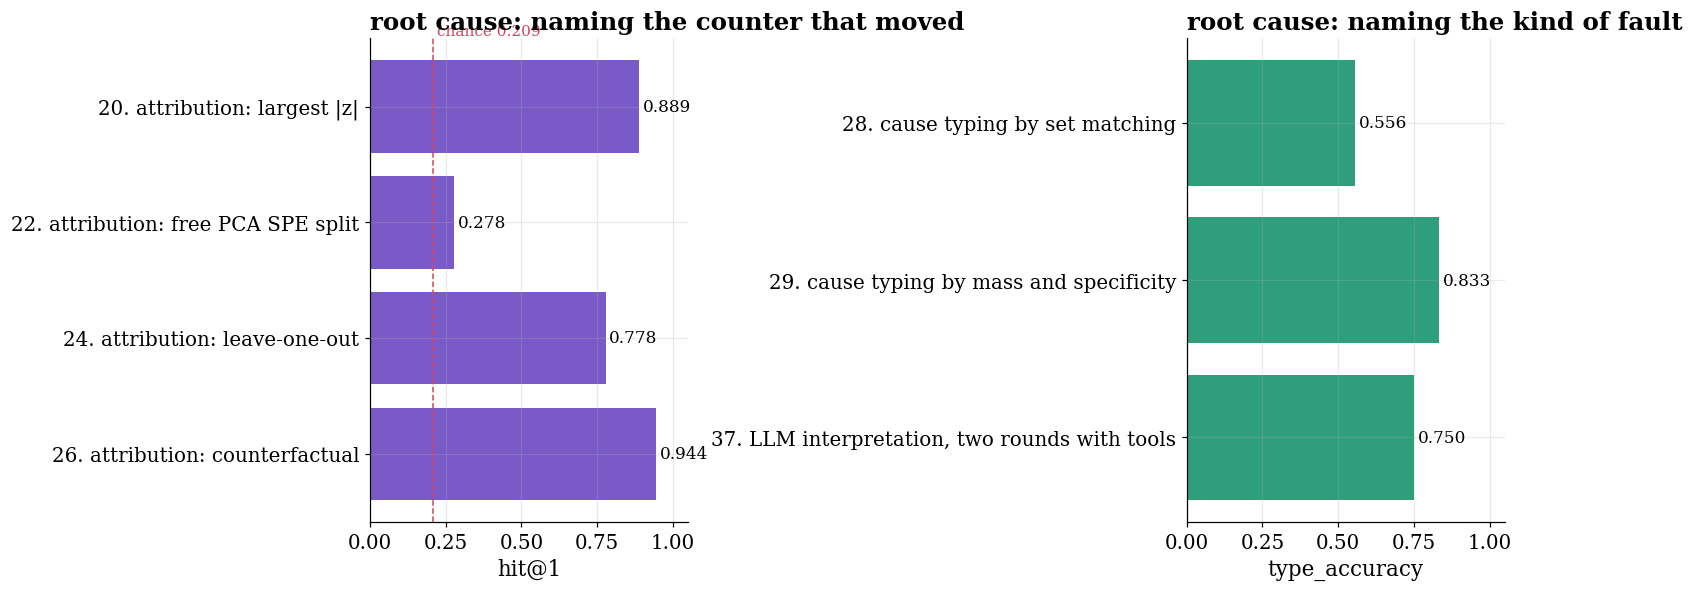

every trial this notebook ran, in order:


,step,trial,metric,value,verdict,next_step
0,1,read INOCTETS as a counter,non_negative_step,0.5030,"0.503 is not a counter, it is a per-interval t...",divide by cadence instead of differencing
1,4,"fixed limit, in_bps only",event_recall,0.2780,misses every incident that does not change volume,"watch all 11 features, not one"
2,5,"marginal baseline, 11 features",event_recall,1.0000,"recall is perfect, so recall can no longer ran...",watch the false-alert rate instead
3,6,baseline keyed on hour of day,false_per_port_day,0.5300,recall still 1.000; 24 buckets,check whether these gaps beat the noise
4,7,baseline keyed on hour of week,false_per_port_day,0.2500,recall still 1.000; 168 buckets,check whether these gaps beat the noise
5,8,"robust scale, median and MAD",false_per_port_day,0.9600,"3 of 11 features have no robust scale at all, ...",measure the uncertainty on every number so far
6,9,bootstrap the scorecard,recall_ci_width,0.0000,the recall interval collapses to a point: the ...,make the task harder so recall can discriminat...
7,11,sweep incident strength,detection_floor,0.0100,the marginal baseline holds to 0.01; Isolation...,bootstrap the weak case before believing the r...
8,12,bootstrap at strength 0.05,ci_width,0.3330,0.833 to 0.944 overlap; the ranking is inside ...,"ask what the multivariate models buy, if not r..."
9,13,contaminate the Phase I reference,recall_lost_at_0.1,0.2780,robust covariance loses 0.000 where the plain ...,add indicators that carry information a single...


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ladder.plot("hit@1", ax=axes[0], colour=C["score"], floor=CHANCE,
            title="root cause: naming the counter that moved")
ladder.plot("type_accuracy", ax=axes[1], colour=C["peer"],
            title="root cause: naming the kind of fault")
plt.show()

print("every trial this notebook ran, in order:")
display(ladder.table()[["step", "trial", "metric", "value", "verdict", "next_step"]])

## 練習

Lab01 與 Lab02 的練習分成兩種，這一節照同一個分法。

### 量一量

1. 第 4 步的 `BUDGET` 改成 0.1，把第 5 到第 8 步重跑一遍。誤報預算砍到五分之一之後，哪一個
   seasonal key 的 recall 先掉？記下來，這就是預算與召回率的兌換率。
2. 第 11 步的 `LOOK_AT` 改成 0.2 與 0.01。在哪一個強度上，marginal baseline 第一次輸給某一個
   多變量模型？如果從來沒有輸過，那件事本身要寫進結論。
3. `DETECTOR` 從 `Mahalanobis` 換成 `PCA T2`，第三部整段重跑。attribution hit@1 動了多少？
   歸因是跟著 detector 走的，換掉 detector 就換掉了解釋。
4. 第 32 步的 margin 掃過 0.05 到 0.40。畫出「敢下結論的次數」對「那些結論的準確率」，這條曲線
   就是你要交給值班人員的東西。

### 想一想

5. `FAULT_SIGNATURE` 現在把 `large_file_backup` 寫成 `avg_pkt_bytes` 加兩個流量欄位，而資料說
   備份期間動得最厲害的是 `multicast_ratio`。表錯了，還是資料錯了？寫下你的判斷和理由，然後說明
   你會怎麼驗證它。
6. 第 30 步的形狀只有四種，判準是三個寫死的閾值。設計第五種形狀，說明哪一種故障需要它，以及你要
   怎麼證明它不是把雜訊分類。
7. 第 31 步兩個 MULTI 事件的 lag 全部是 0。如果取樣間隔從五分鐘縮到十秒，你預期會看到什麼？
   這個預期要花多少錢才驗證得了？
8. 第 37 步的評分只看種類對不對與欄位有沒有編造。一份根因報告還有什麼是該評而沒評的？提出一個
   可以自動算的指標，並且說出它會漏掉什麼。

---
# 結論

## 這條路的形狀

**偵測在第 5 步就做完了。** 十一個欄位、一個時段 baseline、一條校準過的門檻，recall 就是 1.000。
第 6 到第 8 步花的力氣換到的東西全部落在誤差以內。知道什麼時候停手，和知道怎麼往前一樣重要。

**複雜的模型沒有讓偵測變好。** 難度掃描裡最簡單的 marginal baseline 撐到強度 0.01，IsolationForest
在原始強度就開始掉。它們的價值在第三部：可以拆解的分數才能做歸因。

**進階指標的價值也不在 recall。** EWMA、CUSUM、一階差分、滾動相關與組成熵，每一個看得見的故障種類
都不一樣，而那個「看得見什麼」的組合本身就是證據。

**根因才是有落差的地方。** 免費的拆解 0.278，最大偏離量 0.889，counterfactual 0.944。故障種類從
集合比對的低分到份額加權，而那一步一行模型都沒有換。

**最便宜的一步沒有用到任何模型。** 那份變更行事曆讓兩個公告過的事件安靜下來，沒有漏掉任何真故障。

**會說不知道的系統才可信。** 第 32 步把前兩名候選的差距變成一個明確的輸出。分不出來的時候老實說
出來，比自信地報一個錯的名字有用。

## 每一次診斷長什麼樣

回頭看第 21、23、25、28 這四步。形狀完全一樣：量到一個不好的數字，**找出那個數字是被什麼機制造成
的**，機制指定修法。比值的分母在動、平方誤差被尾巴吃掉、相關欄位互相抵銷、平手由排序決定。四個都
不是「換一個更強的模型」可以解決的。

**換模型是最後的手段，不是第一個。**

## 人在最後一格

歸因準確率 0.944，十八次裡錯一次。以這個錯誤率自動執行動作，代價由現場承擔。所以工具回傳的是待
核可，不是已執行。

## 換成你自己的機房

`FAULT_SIGNATURE` 換成你自己的工程表，第三部的量尺就會量你自己的事件。`call_tool()` 指向真的
Prometheus，第四部的 prompt 與評分都不用改。

真值來自你的事件單與變更單。這一節的每一個結論都只在有那兩份紀錄的前提下成立，而建立那兩份紀錄
通常比選演算法難得多。